Loaded 27 beams, Str/w: [9.78, 32.28]

Training GP on 27 beams (2D, alpha=0.001)...
ARD length scales: b=1.114, H=1.384
Best beam: b=4.50, H=14.50 -> Str/w=32.28

Generating recommendations (5 EI + 5 UCB levels, top 5 each)...

EI RECOMMENDATIONS

  xi=0.0001:
 Rank     b      H  Pred_str_w  sigma
    1 5.155 12.008       30.71 0.0362
    2 5.247 12.003       30.65 0.0373
    3 5.049 12.001       30.77 0.0351
    4 5.450 12.055       30.49 0.0385
    5 5.239 12.117       30.67 0.0355

  xi=0.001:
 Rank     b      H  Pred_str_w  sigma
    1 5.247 12.003       30.65 0.0373
    2 5.155 12.008       30.71 0.0362
    3 5.049 12.001       30.77 0.0351
    4 5.450 12.055       30.49 0.0385
    5 5.239 12.117       30.67 0.0355

  xi=0.005:
 Rank     b      H  Pred_str_w  sigma
    1 5.247 12.003       30.65 0.0373
    2 5.155 12.008       30.71 0.0362
    3 5.049 12.001       30.77 0.0351
    4 5.450 12.055       30.49 0.0385
    5 5.239 12.117       30.67 0.0355

  xi=0.01:
 Rank     b      

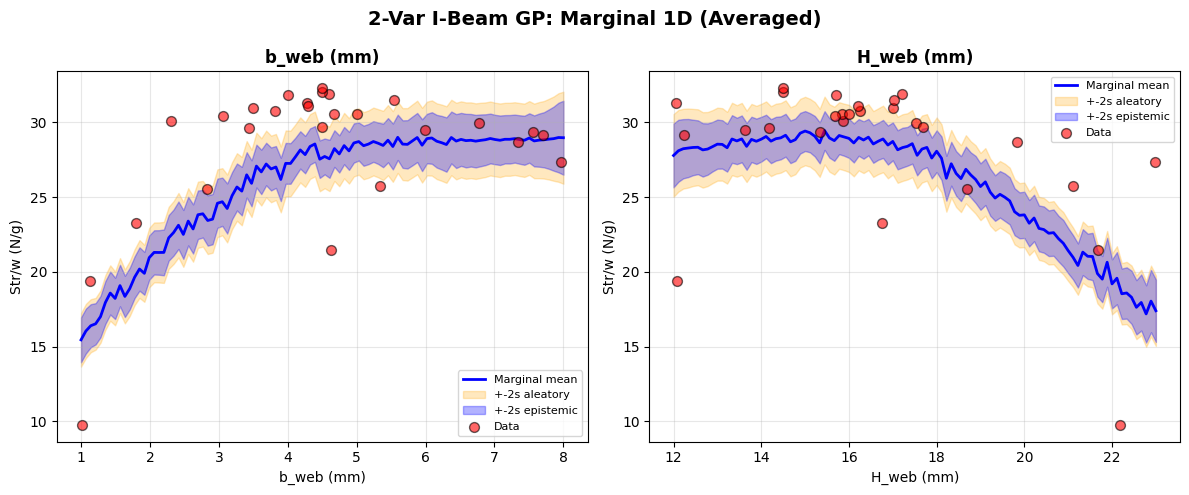

Global 1D slices...


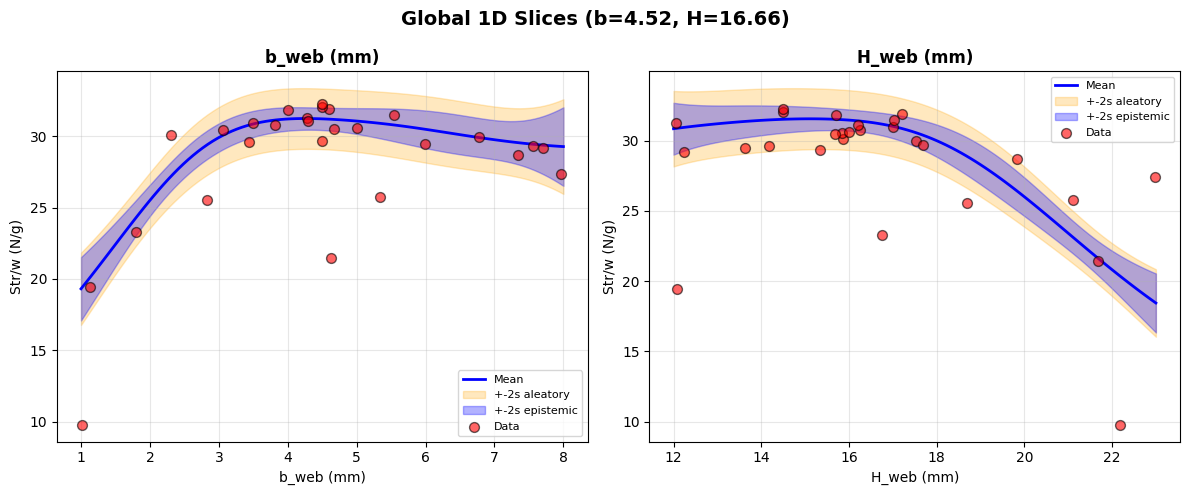

Global 2D contour...


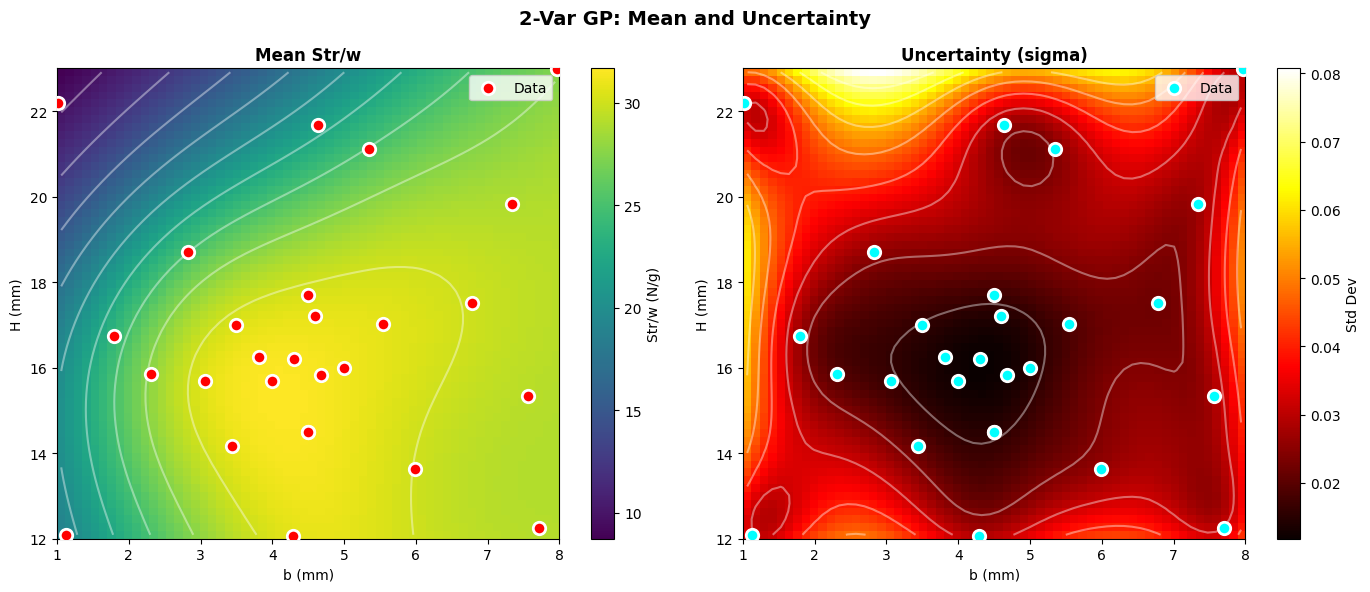


Slice 1: Top 1 Str_w=32.28


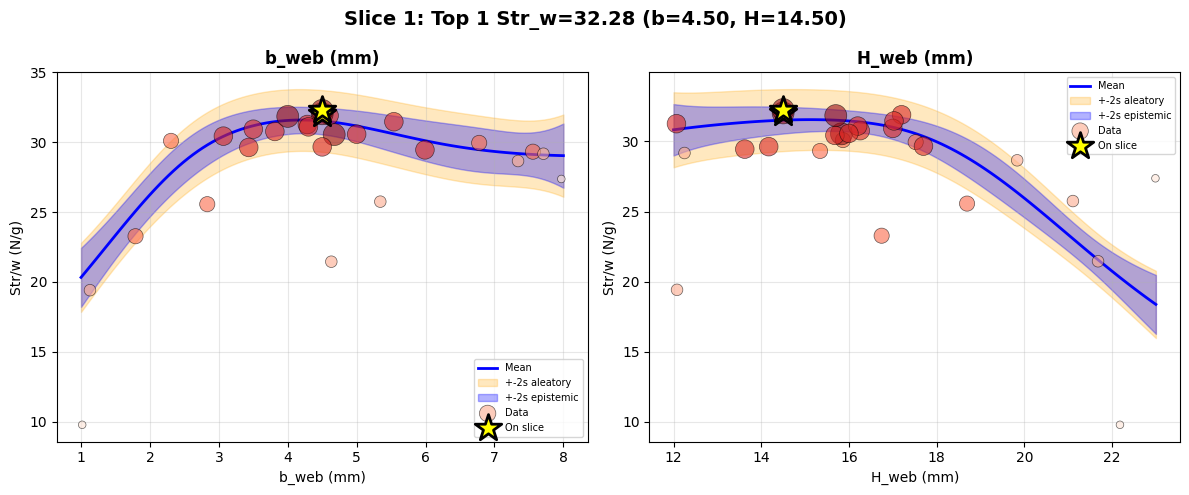

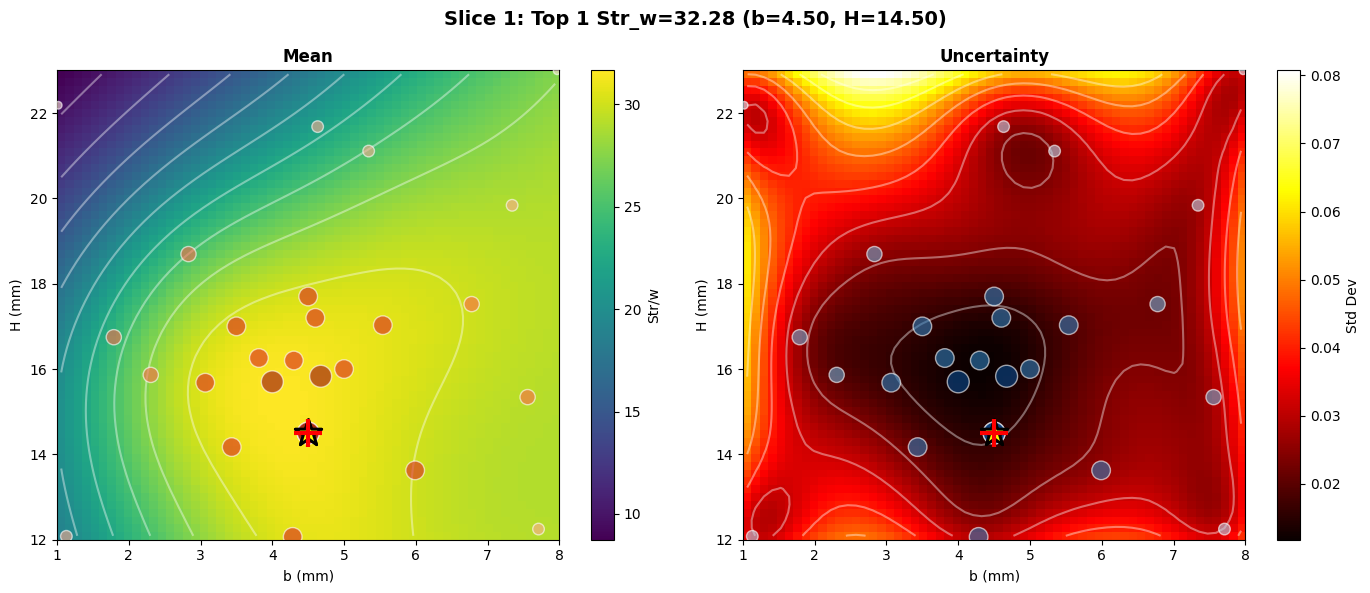


Slice 2: Top 2 Str_w=32.04


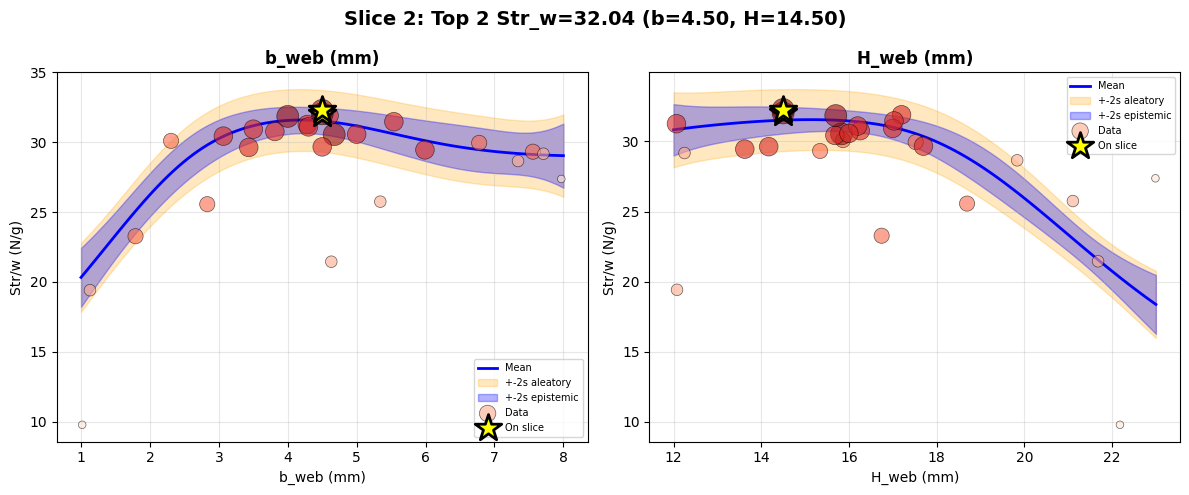

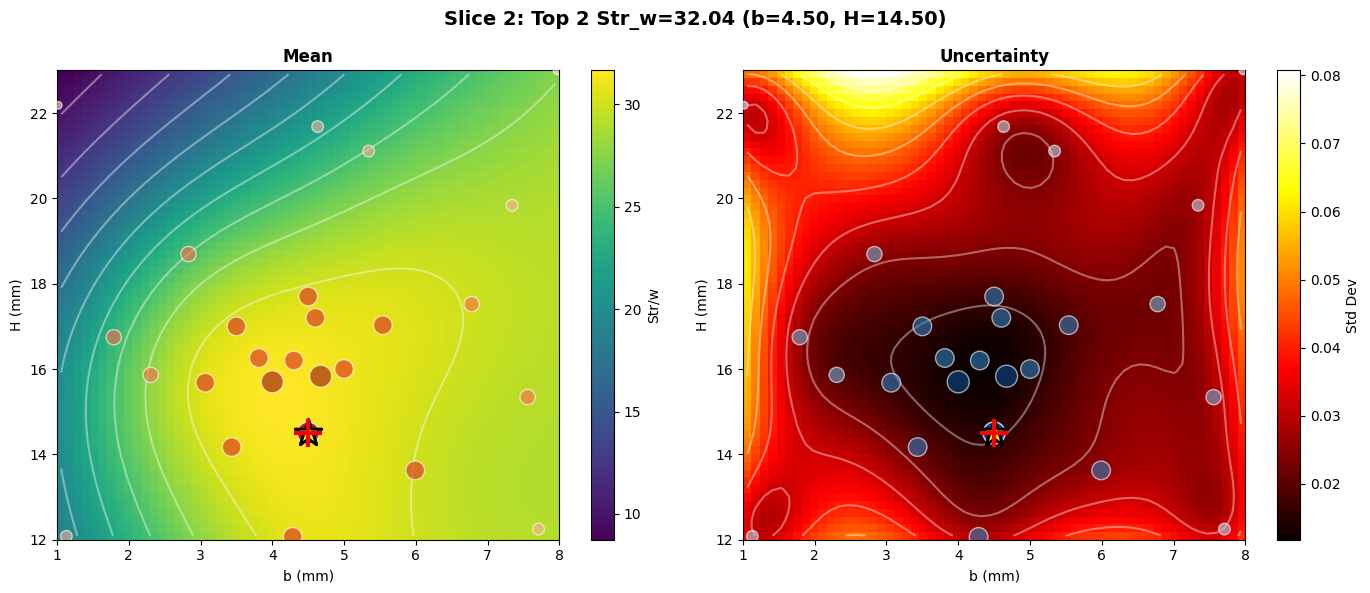


Slice 3: Top 3 Str_w=31.90


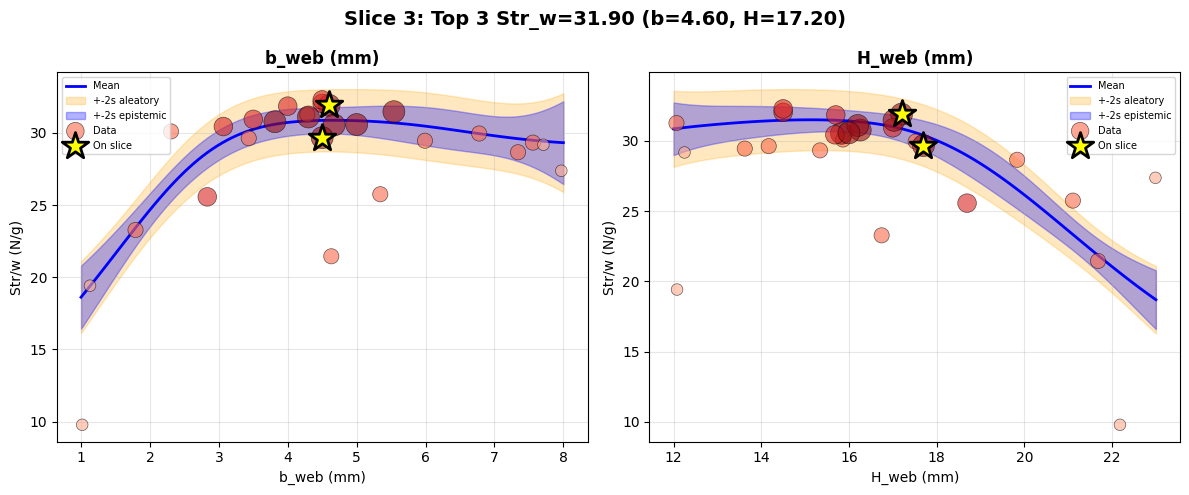

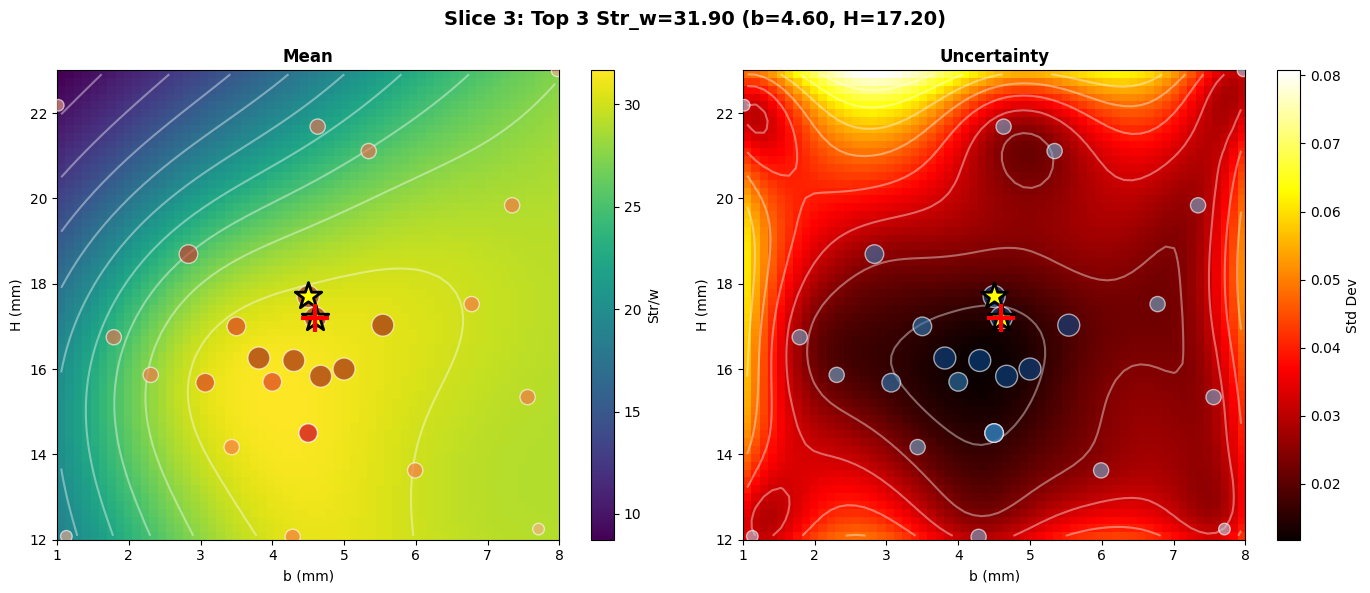


Slice 4: Thin web, short


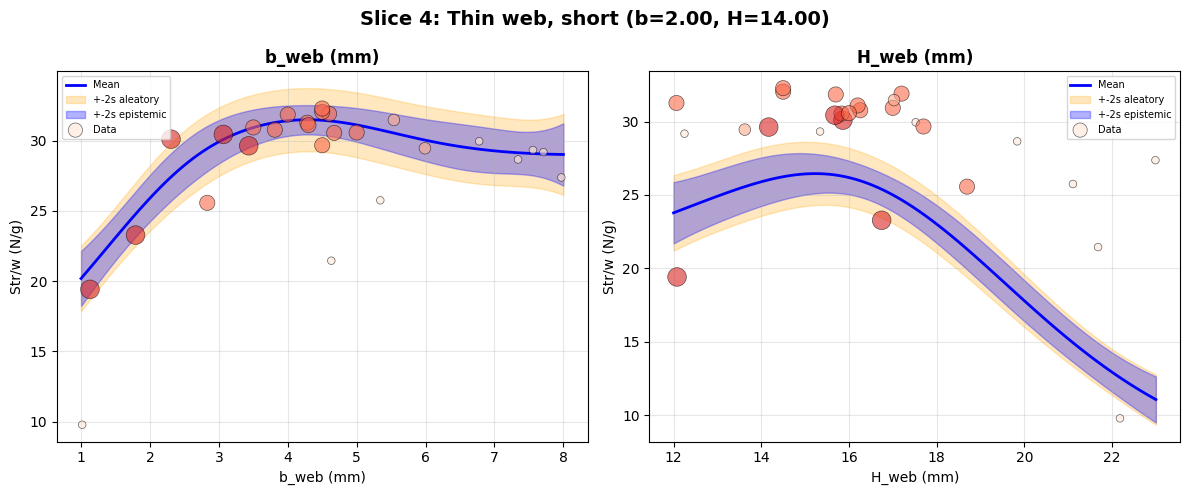

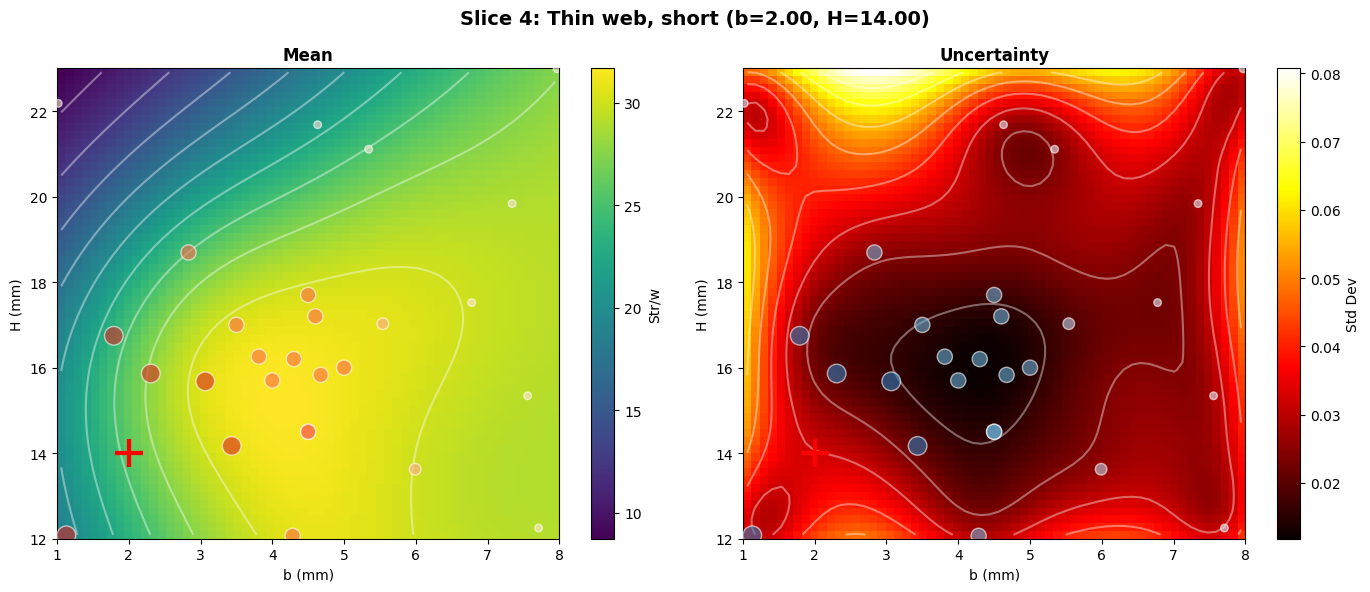


Slice 5: Thick web, tall


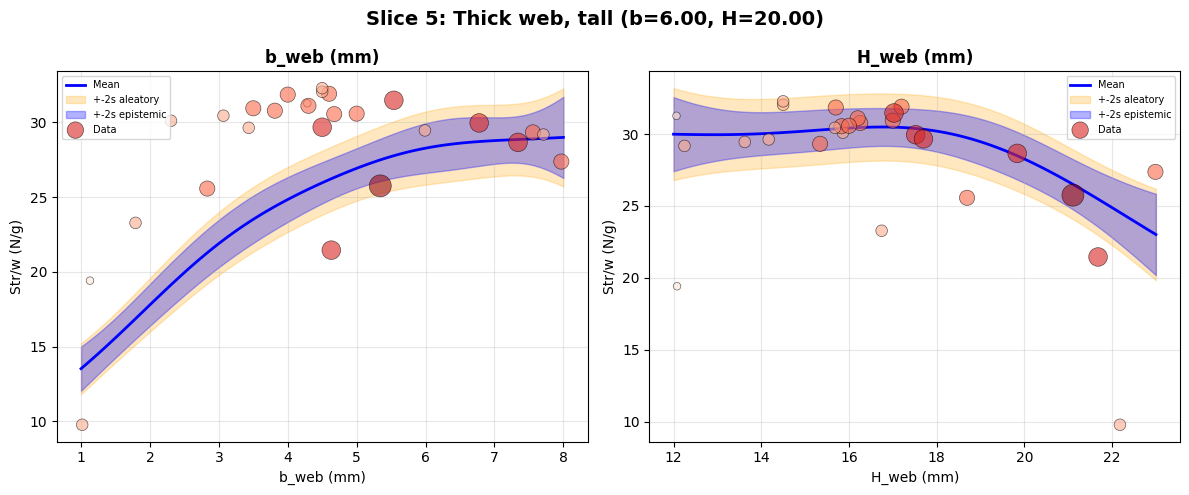

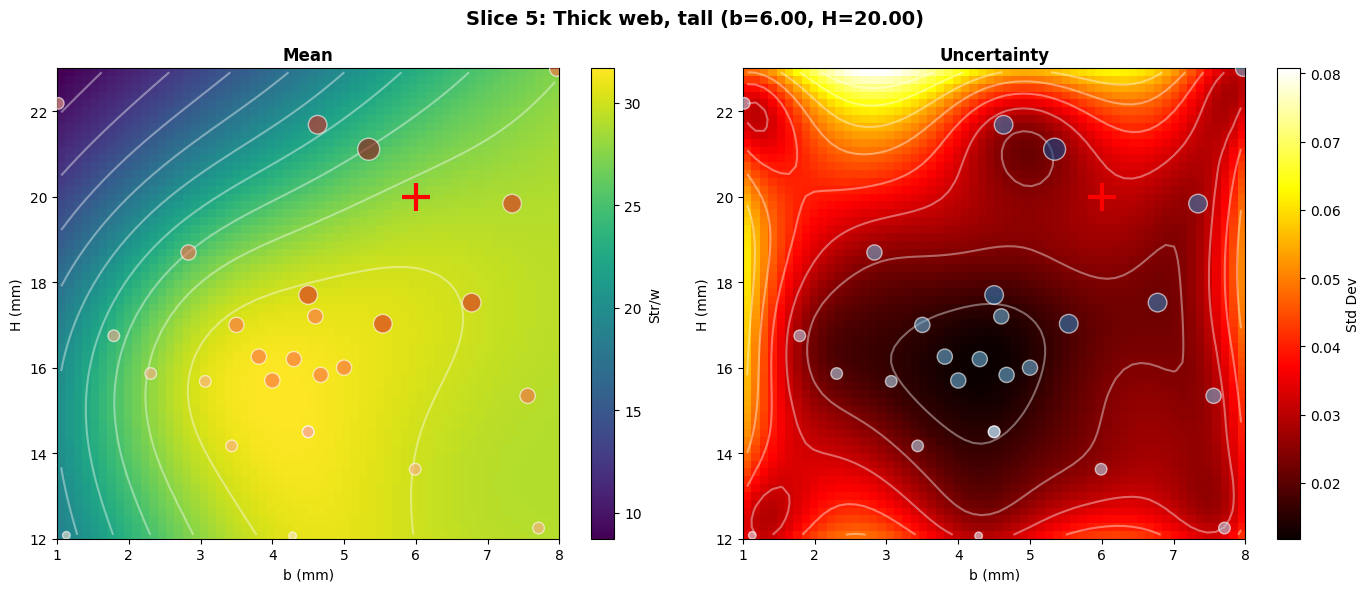

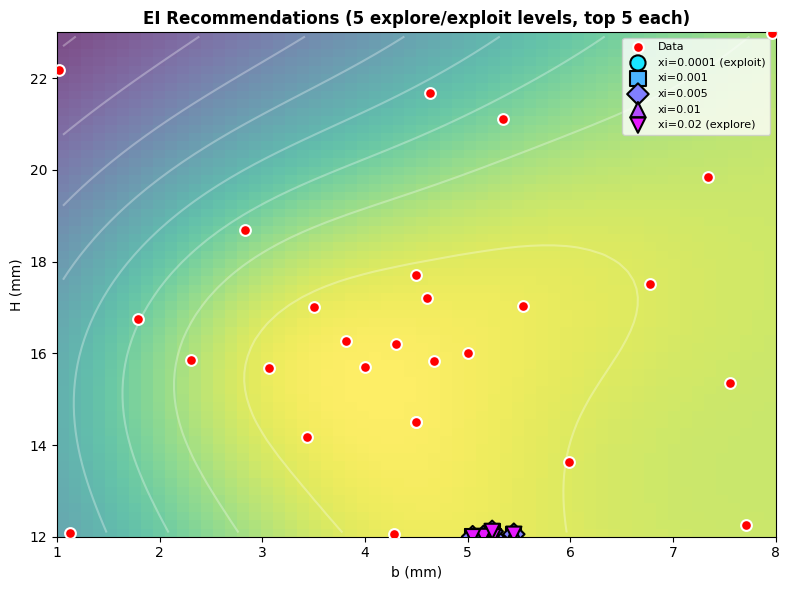

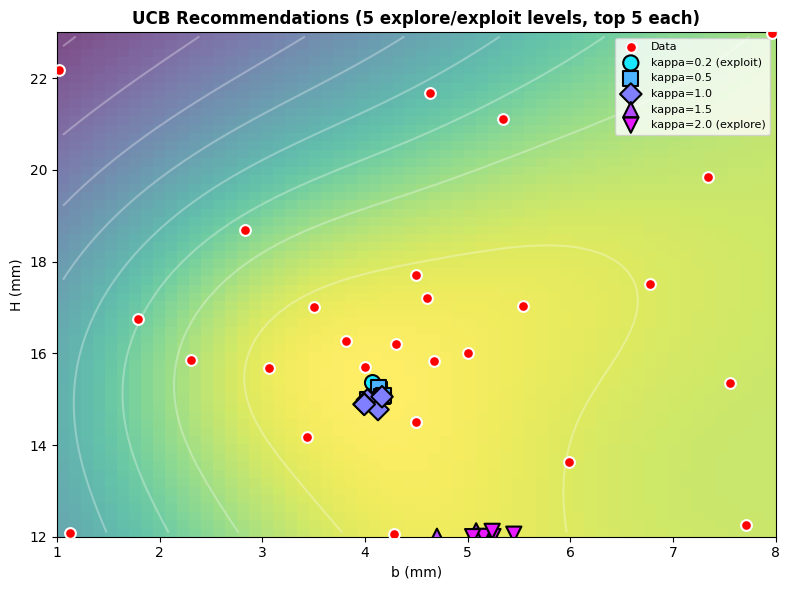


Done!


In [ ]:
"""
I-BEAM 2-VARIABLE GP: b (web thickness) and H (web height)
- GP with alpha=1e-3, log-space target
- Marginal (averaged) 1D plots, global 1D/2D slices, a few named slices
- EI and UCB recommendations at 5 explore/exploit levels (no fantasy)
"""

import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

BOUNDS = {'b': (1.0, 8.0), 'H': (12.0, 23.0)}
PARAM_KEYS = list(BOUNDS.keys())
PARAM_NAMES = ['b_web (mm)', 'H_web (mm)']
NOISE_LEVEL = 1e-3

DATA_URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
            "core-me-data-science-activities-public/main/data/I_beam_data_2var.csv")

# ==========================================
# DATA
# ==========================================
def load_data():
    import urllib.request, io
    print("Downloading data...")
    with urllib.request.urlopen(DATA_URL) as r:
        df = pd.read_csv(io.StringIO(r.read().decode('utf-8')))
    df = df[['b_web_mm', 'H_web_mm', 'Str/w N/g']].dropna()
    df.columns = ['b', 'H', 'str_w']
    print(f"Loaded {len(df)} beams, Str/w: [{df['str_w'].min():.2f}, {df['str_w'].max():.2f}]")
    return df

# ==========================================
# NORMALIZE / DENORMALIZE
# ==========================================
def normalize(X):
    X_n = np.copy(X).astype(float)
    for i, k in enumerate(PARAM_KEYS):
        lo, hi = BOUNDS[k]
        X_n[:, i] = (X[:, i] - lo) / (hi - lo)
    return X_n

def denormalize(X_n):
    X = np.copy(X_n)
    for i, k in enumerate(PARAM_KEYS):
        lo, hi = BOUNDS[k]
        X[:, i] = X_n[:, i] * (hi - lo) + lo
    return X

# ==========================================
# GP
# ==========================================
def train_gp(X_2d, y):
    X_norm = normalize(X_2d)
    y_log = np.log(y)
    y_mean = np.mean(y_log)
    y_cent = y_log - y_mean
    kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
        length_scale=[0.5, 0.5], length_scale_bounds=(0.1, 3.0), nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25,
                                   alpha=NOISE_LEVEL, normalize_y=False)
    gp.fit(X_norm, y_cent)
    return gp, X_norm, y_cent, y_mean

# ==========================================
# ACQUISITION FUNCTIONS
# ==========================================
def ei_acq(gp, X_norm, y_best, xi):
    mu, sigma = gp.predict(X_norm, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z), mu, sigma

def ucb_acq(gp, X_norm, kappa):
    mu, sigma = gp.predict(X_norm, return_std=True)
    return mu + kappa * np.maximum(sigma, 1e-9), mu, sigma

def generate_candidates(n=5000):
    b = np.random.uniform(*BOUNDS['b'], size=n)
    H = np.random.uniform(*BOUNDS['H'], size=n)
    return np.column_stack([b, H])

def recommend(gp, y_cent, y_mean, n_rec=5, n_cand=5000):
    """Return n_rec recommendations for 5 EI and 5 UCB explore/exploit levels."""
    xi_vals  = [0.0001, 0.001, 0.005, 0.01, 0.02]
    kappa_vals = [0.2, 0.5, 1.0, 1.5, 2.0]
    labels_ei = [f"xi={v}" for v in xi_vals]
    labels_ucb = [f"kappa={v}" for v in kappa_vals]
    y_best = y_cent.max()
    cand = generate_candidates(n_cand)
    cand_norm = normalize(cand)

    rows = []
    for xi, lab in zip(xi_vals, labels_ei):
        acq, mu, sig = ei_acq(gp, cand_norm, y_best, xi)
        top = np.argsort(acq)[-n_rec:][::-1]
        for rank, idx in enumerate(top, 1):
            rows.append({
                'Method': 'EI', 'Setting': lab,
                'Rank': rank,
                'b': round(cand[idx, 0], 3), 'H': round(cand[idx, 1], 3),
                'Pred_str_w': round(np.exp(mu[idx] + y_mean), 2),
                'sigma': round(sig[idx], 4),
            })
    for kappa, lab in zip(kappa_vals, labels_ucb):
        acq, mu, sig = ucb_acq(gp, cand_norm, kappa)
        top = np.argsort(acq)[-n_rec:][::-1]
        for rank, idx in enumerate(top, 1):
            rows.append({
                'Method': 'UCB', 'Setting': lab,
                'Rank': rank,
                'b': round(cand[idx, 0], 3), 'H': round(cand[idx, 1], 3),
                'Pred_str_w': round(np.exp(mu[idx] + y_mean), 2),
                'sigma': round(sig[idx], 4),
            })
    return pd.DataFrame(rows)

# ==========================================
# PLOTTING HELPERS
# ==========================================
def _uncertainty_bands(ax, x, mu_r, epistemic, y_mean_scalar):
    aleatory = mu_r * np.sqrt(NOISE_LEVEL)
    total = np.sqrt(epistemic**2 + aleatory**2)
    ax.fill_between(x, mu_r - 2*total, mu_r + 2*total,
                    alpha=0.25, color='orange', label='+-2s aleatory')
    ax.fill_between(x, mu_r - 2*epistemic, mu_r + 2*epistemic,
                    alpha=0.3, color='blue', label='+-2s epistemic')

def get_point_sizes(X_norm, slice_pt):
    d = np.linalg.norm(X_norm - slice_pt, axis=1)
    sizes = np.where(d < 0.15, 250,
            np.where(d < 0.30, 180,
            np.where(d < 0.50, 120,
            np.where(d < 0.75, 70, 30))))
    colors = np.where(d < 0.15, 0.9,
             np.where(d < 0.30, 0.7,
             np.where(d < 0.50, 0.5,
             np.where(d < 0.75, 0.3, 0.1))))
    return sizes, d, colors

# ==========================================
# MARGINAL 1D (AVERAGED)
# ==========================================
def plot_1d_marginal(gp, X_norm, y, y_mean, n_samples=200):
    print("Marginal 1D plots...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('2-Var I-Beam GP: Marginal 1D (Averaged)', fontsize=14, weight='bold')

    for dim in range(2):
        ax = axes[dim]
        x_norm = np.linspace(0, 1, 100)
        mu_all, sig_all = [], []
        for xv in x_norm:
            samp = np.random.rand(n_samples, 2)
            samp[:, dim] = xv
            mu, sig = gp.predict(samp, return_std=True)
            mu_all.append(np.mean(mu))
            sig_all.append(np.mean(sig))
        mu_avg = np.array(mu_all)
        sig_avg = np.array(sig_all)
        mu_r = np.exp(mu_avg + y_mean)
        epistemic = mu_r * sig_avg
        lo, hi = BOUNDS[PARAM_KEYS[dim]]
        x_vals = x_norm * (hi - lo) + lo

        ax.plot(x_vals, mu_r, 'b-', lw=2, label='Marginal mean')
        _uncertainty_bands(ax, x_vals, mu_r, epistemic, y_mean)

        X_den = denormalize(X_norm)
        ax.scatter(X_den[:, dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
        ax.set_xlabel(PARAM_NAMES[dim]); ax.set_ylabel('Str/w (N/g)')
        ax.set_title(PARAM_NAMES[dim], weight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('ibeam2v_marginal_1d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# GLOBAL 1D SLICES
# ==========================================
def plot_1d_global(gp, X_norm, y, y_mean):
    print("Global 1D slices...")
    slice_pt = np.mean(X_norm, axis=0)
    slice_real = denormalize(slice_pt.reshape(1, -1))[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Global 1D Slices (b={slice_real[0]:.2f}, H={slice_real[1]:.2f})',
                 fontsize=14, weight='bold')
    for dim in range(2):
        ax = axes[dim]
        X_test = np.tile(slice_pt, (100, 1))
        X_test[:, dim] = np.linspace(0, 1, 100)
        mu, sig = gp.predict(X_test, return_std=True)
        mu_r = np.exp(mu + y_mean)
        epistemic = mu_r * sig
        x_vals = denormalize(X_test)[:, dim]
        ax.plot(x_vals, mu_r, 'b-', lw=2, label='Mean')
        _uncertainty_bands(ax, x_vals, mu_r, epistemic, y_mean)
        X_den = denormalize(X_norm)
        ax.scatter(X_den[:, dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
        ax.set_xlabel(PARAM_NAMES[dim]); ax.set_ylabel('Str/w (N/g)')
        ax.set_title(PARAM_NAMES[dim], weight='bold')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('ibeam2v_global_1d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# GLOBAL 2D CONTOUR
# ==========================================
def plot_2d_global(gp, X_norm, y, y_mean):
    print("Global 2D contour...")
    res = 60
    gx, gy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
    X_test = np.column_stack([gx.ravel(), gy.ravel()])
    mu, sig = gp.predict(X_test, return_std=True)
    mu_r = np.exp(mu + y_mean).reshape(res, res)
    sig_r = sig.reshape(res, res)

    ext = [BOUNDS['b'][0], BOUNDS['b'][1], BOUNDS['H'][0], BOUNDS['H'][1]]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('2-Var GP: Mean and Uncertainty', fontsize=14, weight='bold')

    X_den = denormalize(X_norm)
    im1 = axes[0].imshow(mu_r, origin='lower', extent=ext, aspect='auto', cmap='viridis')
    axes[0].contour(mu_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[0].scatter(X_den[:, 0], X_den[:, 1], c='red', s=80, ec='white', lw=2, zorder=10, label='Data')
    axes[0].set_xlabel('b (mm)'); axes[0].set_ylabel('H (mm)')
    axes[0].set_title('Mean Str/w', weight='bold'); axes[0].legend()
    plt.colorbar(im1, ax=axes[0], label='Str/w (N/g)')

    im2 = axes[1].imshow(sig_r, origin='lower', extent=ext, aspect='auto', cmap='hot')
    axes[1].contour(sig_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[1].scatter(X_den[:, 0], X_den[:, 1], c='cyan', s=80, ec='white', lw=2, zorder=10, label='Data')
    axes[1].set_xlabel('b (mm)'); axes[1].set_ylabel('H (mm)')
    axes[1].set_title('Uncertainty (sigma)', weight='bold'); axes[1].legend()
    plt.colorbar(im2, ax=axes[1], label='Std Dev')

    plt.tight_layout()
    plt.savefig('ibeam2v_global_2d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# SLICE 1D
# ==========================================
def plot_slice_1d(gp, X_norm, y, y_mean, slice_pt_norm, name, idx):
    slice_real = denormalize(slice_pt_norm.reshape(1, -1))[0]
    sizes, dists, colors = get_point_sizes(X_norm, slice_pt_norm)
    on_slice = dists < 0.1

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Slice {idx}: {name} (b={slice_real[0]:.2f}, H={slice_real[1]:.2f})',
                 fontsize=14, weight='bold')
    for dim in range(2):
        ax = axes[dim]
        X_test = np.tile(slice_pt_norm, (100, 1))
        X_test[:, dim] = np.linspace(0, 1, 100)
        mu, sig = gp.predict(X_test, return_std=True)
        mu_r = np.exp(mu + y_mean)
        epistemic = mu_r * sig
        x_vals = denormalize(X_test)[:, dim]
        ax.plot(x_vals, mu_r, 'b-', lw=2, label='Mean')
        _uncertainty_bands(ax, x_vals, mu_r, epistemic, y_mean)
        X_den = denormalize(X_norm)
        ax.scatter(X_den[:, dim], y, s=sizes, c=colors, cmap='Reds',
                  vmin=0, vmax=1, alpha=0.6, ec='black', lw=0.5, zorder=5, label='Data')
        if np.any(on_slice):
            ax.scatter(X_den[on_slice, dim], y[on_slice], s=400, marker='*',
                      c='yellow', ec='black', lw=2, zorder=10, label='On slice')
        ax.set_xlabel(PARAM_NAMES[dim]); ax.set_ylabel('Str/w (N/g)')
        ax.set_title(PARAM_NAMES[dim], weight='bold')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout()
    clean = name.replace('#','num').replace(' ','_').replace('(','').replace(')','').replace('=','').replace('/','_')
    plt.savefig(f'ibeam2v_slice_{idx:02d}_{clean}_1d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# SLICE 2D
# ==========================================
def plot_slice_2d(gp, X_norm, y, y_mean, slice_pt_norm, name, idx):
    slice_real = denormalize(slice_pt_norm.reshape(1, -1))[0]
    sizes, dists, colors = get_point_sizes(X_norm, slice_pt_norm)
    on_slice = dists < 0.1

    res = 60
    gx, gy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
    X_test = np.column_stack([gx.ravel(), gy.ravel()])
    mu, sig = gp.predict(X_test, return_std=True)
    mu_r = np.exp(mu + y_mean).reshape(res, res)
    sig_r = sig.reshape(res, res)
    ext = [BOUNDS['b'][0], BOUNDS['b'][1], BOUNDS['H'][0], BOUNDS['H'][1]]

    X_den = denormalize(X_norm)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Slice {idx}: {name} (b={slice_real[0]:.2f}, H={slice_real[1]:.2f})',
                 fontsize=14, weight='bold')

    im1 = axes[0].imshow(mu_r, origin='lower', extent=ext, aspect='auto', cmap='viridis')
    axes[0].contour(mu_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[0].scatter(X_den[:, 0], X_den[:, 1], s=sizes, c=colors, cmap='Reds',
                   vmin=0, vmax=1, alpha=0.6, ec='white', lw=1, zorder=5)
    if np.any(on_slice):
        axes[0].scatter(X_den[on_slice, 0], X_den[on_slice, 1], s=400, marker='*',
                       c='yellow', ec='black', lw=2, zorder=10)
    axes[0].plot(slice_real[0], slice_real[1], 'r+', ms=20, mew=3, zorder=11)
    axes[0].set_xlabel('b (mm)'); axes[0].set_ylabel('H (mm)')
    axes[0].set_title('Mean', weight='bold')
    plt.colorbar(im1, ax=axes[0], label='Str/w')

    im2 = axes[1].imshow(sig_r, origin='lower', extent=ext, aspect='auto', cmap='hot')
    axes[1].contour(sig_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[1].scatter(X_den[:, 0], X_den[:, 1], s=sizes, c=colors, cmap='Blues',
                   vmin=0, vmax=1, alpha=0.6, ec='white', lw=1, zorder=5)
    if np.any(on_slice):
        axes[1].scatter(X_den[on_slice, 0], X_den[on_slice, 1], s=400, marker='*',
                       c='yellow', ec='black', lw=2, zorder=10)
    axes[1].plot(slice_real[0], slice_real[1], 'r+', ms=20, mew=3, zorder=11)
    axes[1].set_xlabel('b (mm)'); axes[1].set_ylabel('H (mm)')
    axes[1].set_title('Uncertainty', weight='bold')
    plt.colorbar(im2, ax=axes[1], label='Std Dev')

    plt.tight_layout()
    clean = name.replace('#','num').replace(' ','_').replace('(','').replace(')','').replace('=','').replace('/','_')
    plt.savefig(f'ibeam2v_slice_{idx:02d}_{clean}_2d.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# RECOMMENDATION PLOT
# ==========================================
def plot_recommendations(gp, X_norm, y, y_mean, rec_df):
    """Plot recommendations on the 2D contour."""
    res = 60
    gx, gy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
    X_test = np.column_stack([gx.ravel(), gy.ravel()])
    mu, _ = gp.predict(X_test, return_std=True)
    mu_r = np.exp(mu + y_mean).reshape(res, res)
    ext = [BOUNDS['b'][0], BOUNDS['b'][1], BOUNDS['H'][0], BOUNDS['H'][1]]
    X_den = denormalize(X_norm)

    for method in ['EI', 'UCB']:
        sub = rec_df[rec_df['Method'] == method]
        settings = sub['Setting'].unique()

        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.imshow(mu_r, origin='lower', extent=ext, aspect='auto', cmap='viridis', alpha=0.7)
        ax.contour(mu_r, origin='lower', extent=ext, colors='white', alpha=0.3, levels=8)
        ax.scatter(X_den[:, 0], X_den[:, 1], c='red', s=60, ec='white', lw=1.5, zorder=10, label='Data')

        markers = ['o', 's', 'D', '^', 'v']
        cmap = plt.cm.cool(np.linspace(0.1, 0.9, len(settings)))
        for i, (setting, color) in enumerate(zip(settings, cmap)):
            ss = sub[sub['Setting'] == setting]
            exploit_label = 'exploit' if i == 0 else ('explore' if i == len(settings)-1 else '')
            label = f"{setting}" + (f" ({exploit_label})" if exploit_label else "")
            ax.scatter(ss['b'], ss['H'], c=[color]*len(ss), s=120, marker=markers[i % len(markers)],
                      ec='black', lw=1.5, zorder=11, label=label)

        ax.set_xlabel('b (mm)'); ax.set_ylabel('H (mm)')
        ax.set_title(f'{method} Recommendations (5 explore/exploit levels, top 5 each)',
                     fontsize=12, weight='bold')
        ax.legend(fontsize=8, loc='best')
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
        plt.tight_layout()
        plt.savefig(f'ibeam2v_recs_{method.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()

# ==========================================
# MAIN
# ==========================================
if __name__ == "__main__":
    np.random.seed(42)

    df = load_data()
    X_2d = df[['b', 'H']].values
    y = df['str_w'].values

    print(f"\nTraining GP on {len(y)} beams (2D, alpha={NOISE_LEVEL})...")
    gp, X_norm, y_cent, y_mean = train_gp(X_2d, y)
    scales = gp.kernel_.k2.length_scale
    print(f"ARD length scales: b={scales[0]:.3f}, H={scales[1]:.3f}")

    best_idx = np.argmax(y)
    print(f"Best beam: b={X_2d[best_idx,0]:.2f}, H={X_2d[best_idx,1]:.2f} -> Str/w={y[best_idx]:.2f}")

    # Recommendations
    print("\nGenerating recommendations (5 EI + 5 UCB levels, top 5 each)...")
    rec_df = recommend(gp, y_cent, y_mean)
    for method in ['EI', 'UCB']:
        print(f"\n{'='*60}\n{method} RECOMMENDATIONS\n{'='*60}")
        sub = rec_df[rec_df['Method'] == method]
        for setting in sub['Setting'].unique():
            ss = sub[sub['Setting'] == setting]
            print(f"\n  {setting}:")
            print(ss[['Rank', 'b', 'H', 'Pred_str_w', 'sigma']].to_string(index=False))

    # Plots
    plot_1d_marginal(gp, X_norm, y, y_mean)
    plot_1d_global(gp, X_norm, y, y_mean)
    plot_2d_global(gp, X_norm, y, y_mean)

    # Slices: top 3 beams + a few interesting points
    slices = []
    top3 = np.argsort(y)[-3:][::-1]
    for i, idx in enumerate(top3):
        slices.append((X_2d[idx], f"Top {i+1} Str_w={y[idx]:.2f}"))
    slices.append((np.array([2.0, 14.0]), "Thin web, short"))
    slices.append((np.array([6.0, 20.0]), "Thick web, tall"))

    for si, (pt, name) in enumerate(slices):
        pt_norm = normalize(pt.reshape(1, -1))[0]
        print(f"\nSlice {si+1}: {name}")
        plot_slice_1d(gp, X_norm, y, y_mean, pt_norm, name, si+1)
        plot_slice_2d(gp, X_norm, y, y_mean, pt_norm, name, si+1)

    plot_recommendations(gp, X_norm, y, y_mean, rec_df)
    print("\nDone!")


Reparameterized data (dH, R):
beam      b      H      dH       R   Str/w
   1   4.63  21.68    3.97   0.896   21.45
   2   2.83  18.69   -0.16   0.698   25.57
   3   6.78  17.52    0.77   1.456   29.95
   4   2.31  15.86   -3.43   0.989   30.10
   5   7.34  19.84    3.29   1.641   28.66
   6   4.28  12.07   -5.83   1.572   31.27
   7   1.79  16.75   -3.06   0.869   23.27
   8   5.99  13.62   -3.44   1.536   29.45
   9   5.34  21.11    3.75   1.071   25.75
  10   3.43  14.17   -4.24   1.246   29.63
  11   7.56  15.34   -1.12   1.708   29.32
  12   1.02  22.18    1.34   0.267    9.78
  13   1.13  12.08   -8.58   1.516   19.41
  14   7.97  22.99    6.66   2.051   27.37
  15   4.60  17.20   -0.52   1.030   31.90
  16   7.71  12.25   -4.16   1.925   29.18
  17   4.67  15.83   -1.85   1.155   30.54
  18   3.81  16.26   -1.91   1.023   30.77
  19   3.07  15.68   -2.99   1.038   30.44
  20   4.50  14.50   -3.28   1.277   32.04
  21   4.30  16.20   -1.69   1.077   31.10
  22   3.50  17.00   -1.

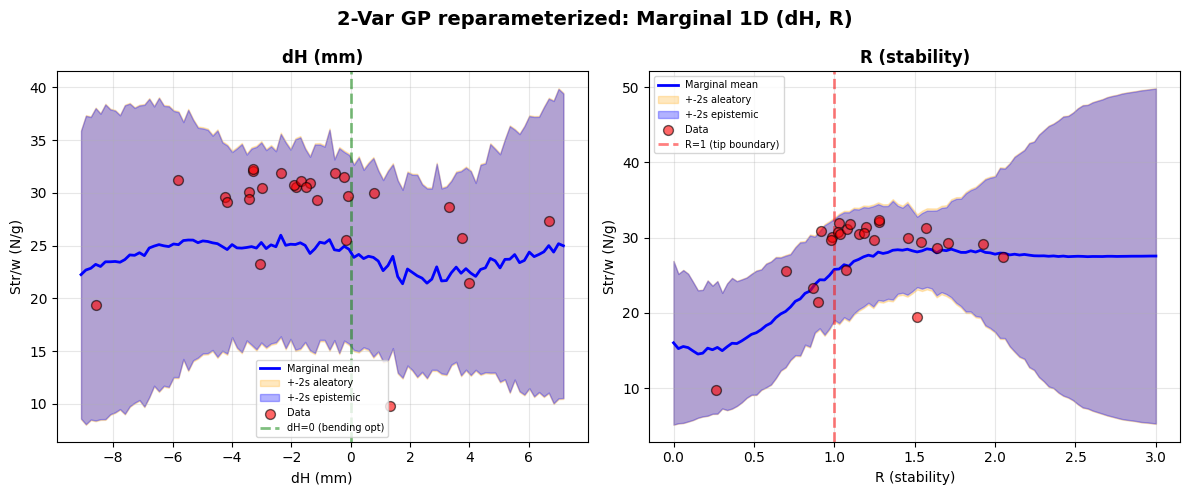

Global 1D slices (dH, R)...


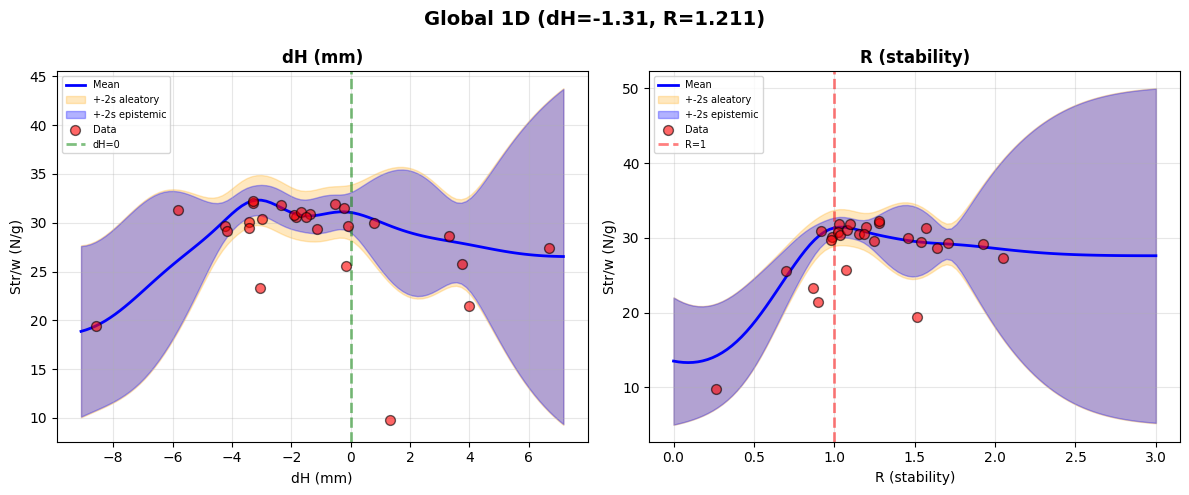

Global 2D contour (dH, R)...


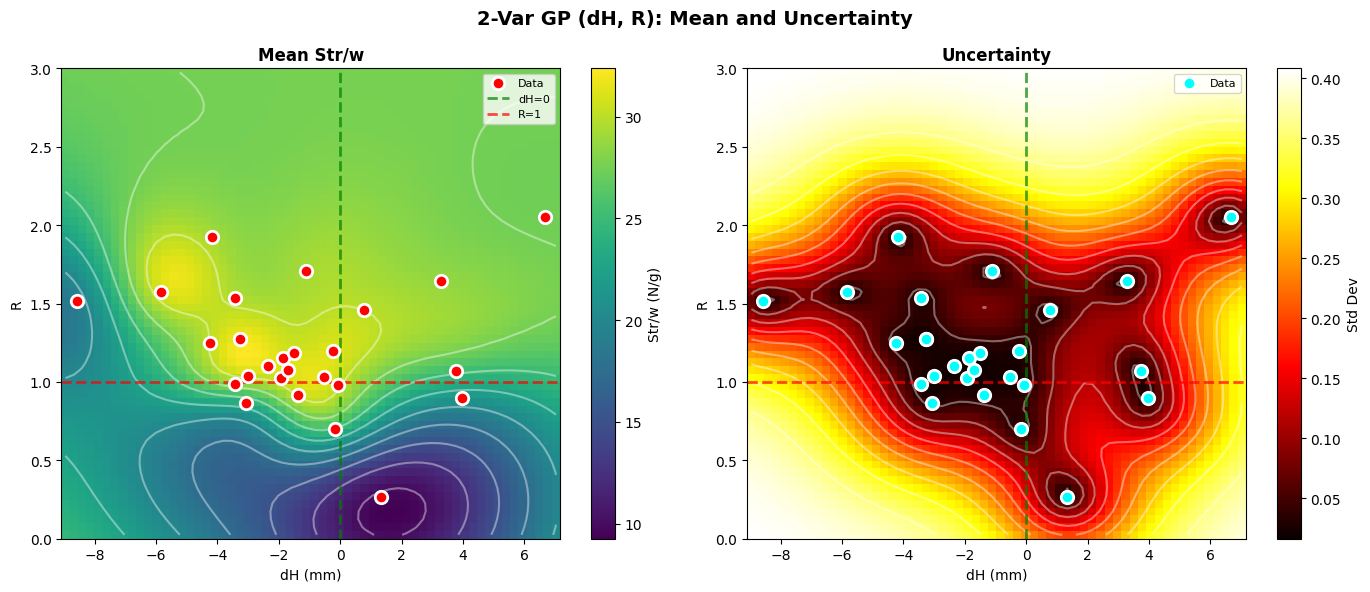

Slice 1D plots (dH, R)...


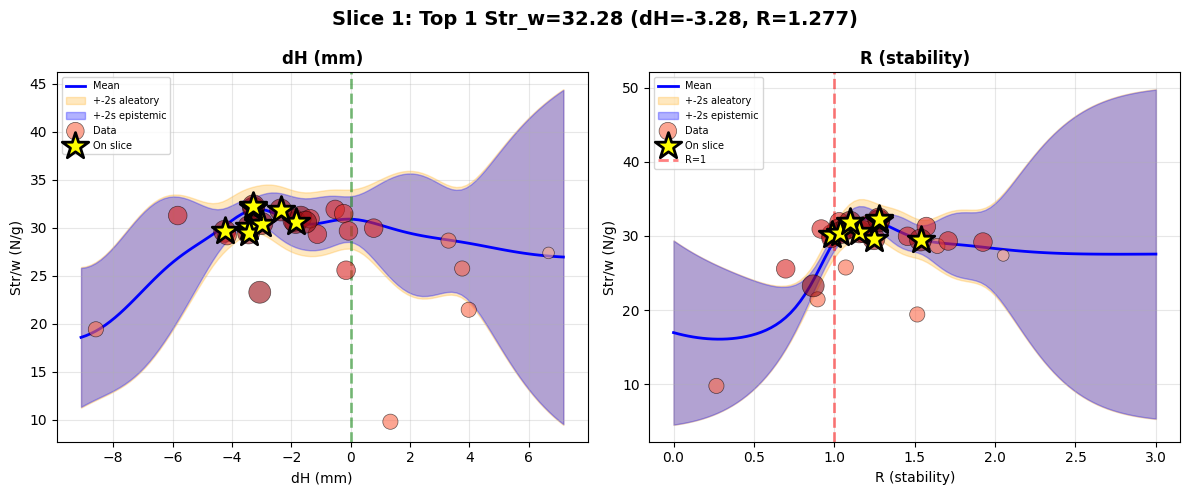

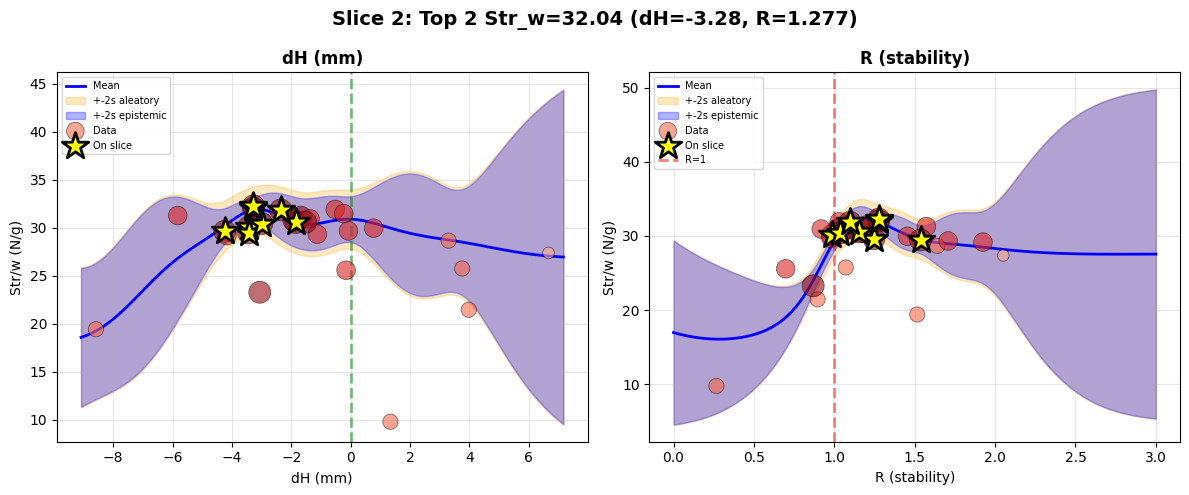

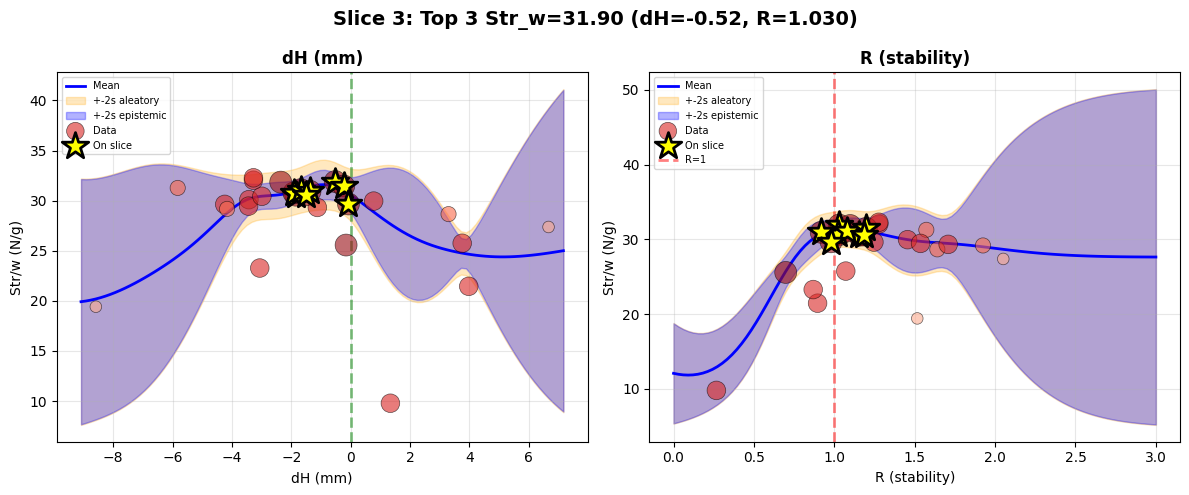

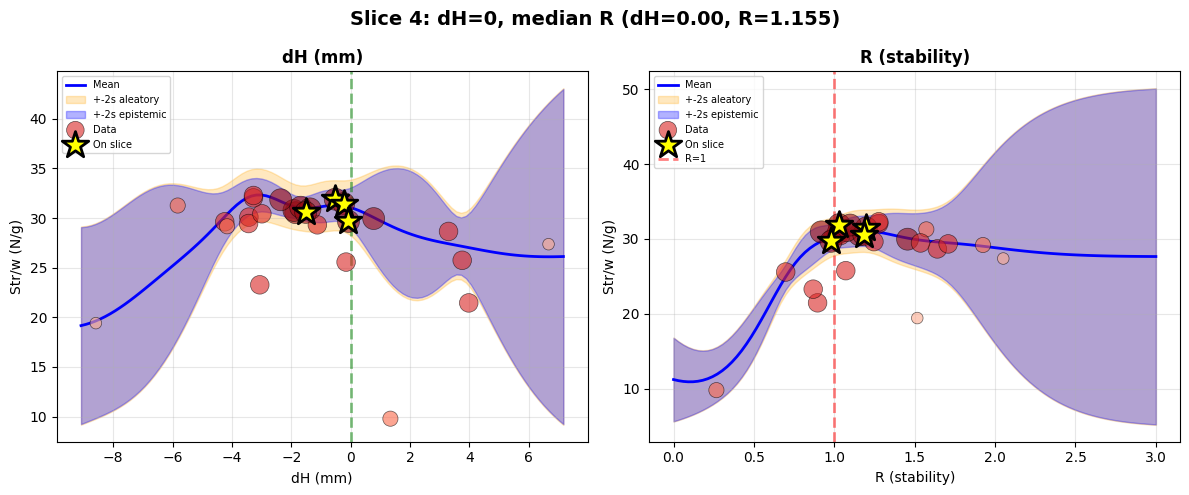

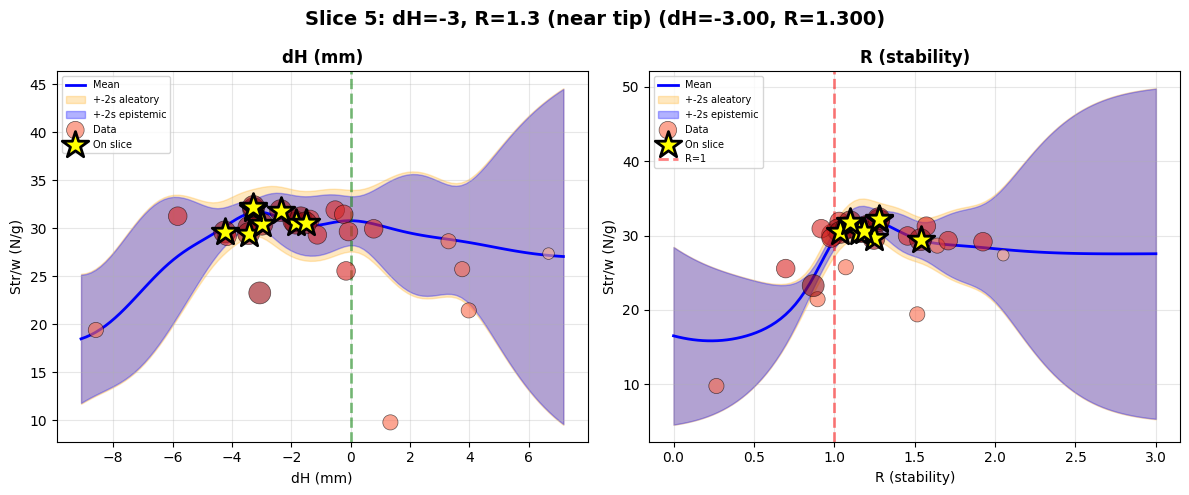


Recommendations in (dH, R) space...

EI RECOMMENDATIONS (dH, R space)

  xi=0.0001:
 Rank     b      H    dH      R  Pred  sigma
    1 6.501 22.910 6.053 1.4634 27.99 0.2590
    2 6.360 22.903 5.989 1.4149 27.92 0.2587
    3 6.253 22.964 6.007 1.3801 27.81 0.2609
    4 6.510 22.823 5.969 1.4640 28.02 0.2542
    5 6.221 22.968 5.997 1.3694 27.77 0.2604

  xi=0.001:
 Rank     b      H    dH      R  Pred  sigma
    1 6.501 22.910 6.053 1.4634 27.99 0.2590
    2 6.360 22.903 5.989 1.4149 27.92 0.2587
    3 6.253 22.964 6.007 1.3801 27.81 0.2609
    4 6.510 22.823 5.969 1.4640 28.02 0.2542
    5 6.221 22.968 5.997 1.3694 27.77 0.2604

  xi=0.005:
 Rank     b      H    dH      R  Pred  sigma
    1 6.501 22.910 6.053 1.4634 27.99 0.2590
    2 6.360 22.903 5.989 1.4149 27.92 0.2587
    3 6.253 22.964 6.007 1.3801 27.81 0.2609
    4 6.510 22.823 5.969 1.4640 28.02 0.2542
    5 6.221 22.968 5.997 1.3694 27.77 0.2604

  xi=0.01:
 Rank     b      H    dH      R  Pred  sigma
    1 6.501 22.910 6.0

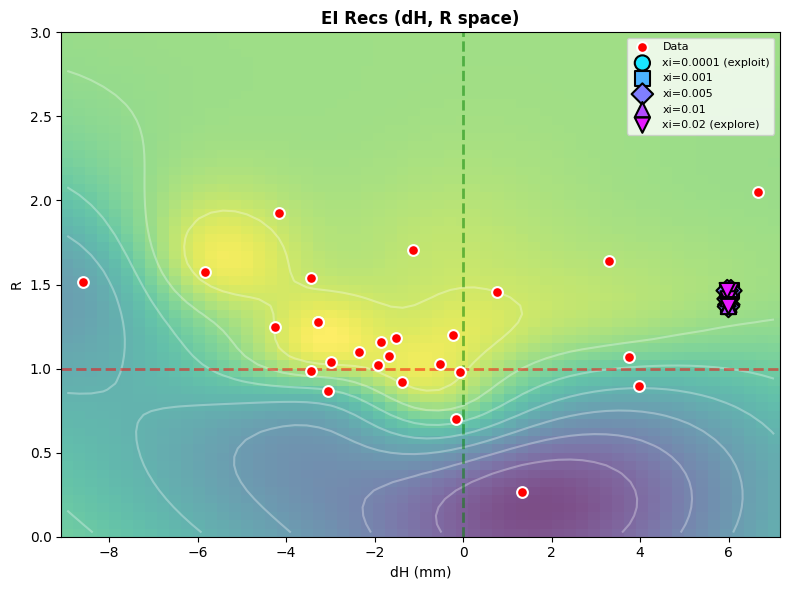

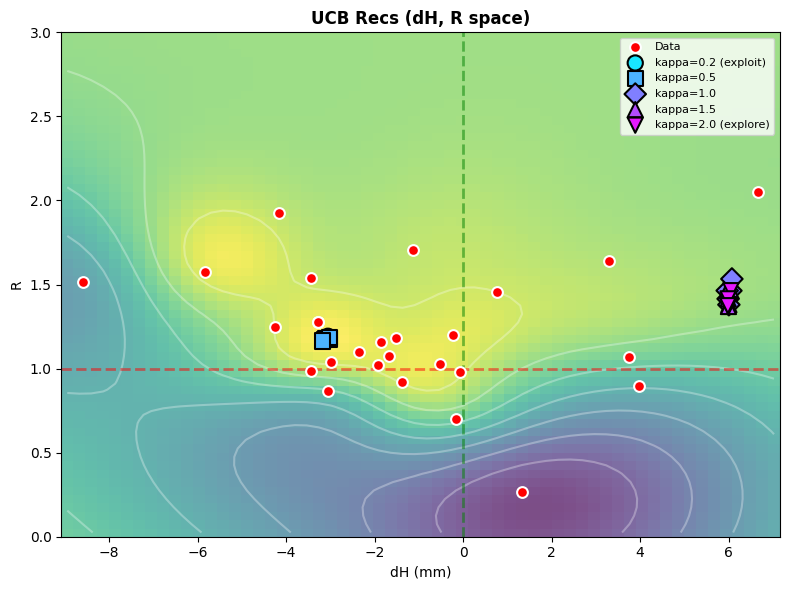


Done (dH, R reparameterization)!


In [ ]:
# ==========================================
# REPARAMETERIZE: (b, H) -> (dH, R)
# ==========================================
# dH = H - H_opt(b): deviation from bending-optimal web height
# R  = Mcr / Myield: lateral-torsional stability ratio
# B and r are fixed (B=16mm, r=0) since 2var experiment doesn't vary them.

TOTAL_HEIGHT = 25.0
B_FIXED = 16.0
YIELD_STRENGTH = 81.8e6      # Pa, Sunlu PLA+ 2.0 flexural strength (ASTM D790)
E_MODULUS = 2.74e9            # Pa, Sunlu PLA+ 2.0 flexural modulus
G_MODULUS = E_MODULUS / 2.6
C1_3PT = 1.35
MATERIAL_DENSITY = 1210       # kg/m^3, Sunlu PLA+ 2.0
LENGTH_M_REPARAM = 0.2023
Y_MAX = TOTAL_HEIGHT / 2e3    # 0.0125 m, NA to extreme fiber

def _beta_timo(t, a):
    """Timoshenko correction for rectangular torsion constant."""
    if a <= 0 or t <= 0: return 1.0/3.0
    r = min(t, a) / max(t, a)
    return (1.0/3.0) * (1.0 - 0.63*r + 0.052*r**5)

def calc_I_simple(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return (b_m * H_m**3)/12 + 2*((B_m * h_m**3)/12 + B_m*h_m*((H_m+h_m)/2)**2)

def calc_Iy_simple(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return (H_m * b_m**3)/12 + 2*(h_m * B_m**3)/12

def calc_J_simple(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    J_web = _beta_timo(min(b_m, H_m), max(b_m, H_m)) * max(b_m, H_m) * min(b_m, H_m)**3
    J_fl  = _beta_timo(min(h_m, B_m), max(h_m, B_m)) * max(h_m, B_m) * min(h_m, B_m)**3
    return J_web + 2 * J_fl

def calc_mass_simple(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return MATERIAL_DENSITY * LENGTH_M_REPARAM * (H_m*b_m + 2*h_m*B_m) * 1000

def calc_str_w_simple(H, B, b):
    h = (TOTAL_HEIGHT - H) / 2.0
    strength = (4 * YIELD_STRENGTH * calc_I_simple(H, h, B, b)) / (Y_MAX * LENGTH_M_REPARAM)
    mass = calc_mass_simple(H, h, B, b)
    return strength / mass if mass > 0 else 0.0

def find_H_opt_simple(b, B=B_FIXED):
    from scipy.optimize import minimize_scalar
    def obj(H):
        if H < 12.0 or H > 23.4: return 1e10
        h = (TOTAL_HEIGHT - H) / 2.0
        if h < 0 or h > 6.5: return 1e10
        return -calc_str_w_simple(H, B, b)
    return minimize_scalar(obj, bounds=(12.0, 23.4), method='bounded').x

def stability_ratio_simple(H, h, B, b):
    Iy = calc_Iy_simple(H, h, B, b)
    J = calc_J_simple(H, h, B, b)
    if Iy <= 0 or J <= 0: return 0.0
    Mcr = (C1_3PT * np.pi / LENGTH_M_REPARAM) * np.sqrt(E_MODULUS * Iy * G_MODULUS * J)
    Ix = calc_I_simple(H, h, B, b)
    My = YIELD_STRENGTH * Ix / Y_MAX if Y_MAX > 0 else 0.0
    return Mcr / My if My > 0 else 0.0

def bH_to_dHR(b_arr, H_arr):
    """Convert arrays of (b, H) to (dH, R)."""
    dH = np.zeros(len(b_arr))
    R = np.zeros(len(b_arr))
    for i in range(len(b_arr)):
        H_opt = find_H_opt_simple(b_arr[i], B_FIXED)
        dH[i] = H_arr[i] - H_opt
        h = (TOTAL_HEIGHT - H_arr[i]) / 2.0
        R[i] = stability_ratio_simple(H_arr[i], h, B_FIXED, b_arr[i]) if h > 0 else 0.0
    return dH, R

# Transform original data
dH_data, R_data = bH_to_dHR(X_2d[:, 0], X_2d[:, 1])
X_dHR = np.column_stack([dH_data, R_data])

print("Reparameterized data (dH, R):")
print(f"{'beam':>4} {'b':>6} {'H':>6} {'dH':>7} {'R':>7} {'Str/w':>7}")
for i in range(len(y)):
    print(f"{i+1:4d} {X_2d[i,0]:6.2f} {X_2d[i,1]:6.2f} {dH_data[i]:7.2f} {R_data[i]:7.3f} {y[i]:7.2f}")

# Set up bounds for (dH, R) space
dH_range = (dH_data.min() - 0.5, dH_data.max() + 0.5)
R_range = (0.0, max(R_data.max() * 1.1, 3.0))
BOUNDS_dHR = {'dH': dH_range, 'R': R_range}
PARAM_KEYS_dHR = list(BOUNDS_dHR.keys())
PARAM_NAMES_dHR = ['dH (mm)', 'R (stability)']

def normalize_dHR(X):
    X_n = np.copy(X).astype(float)
    for i, k in enumerate(PARAM_KEYS_dHR):
        lo, hi = BOUNDS_dHR[k]
        X_n[:, i] = (X[:, i] - lo) / (hi - lo)
    return X_n

def denormalize_dHR(X_n):
    X = np.copy(X_n)
    for i, k in enumerate(PARAM_KEYS_dHR):
        lo, hi = BOUNDS_dHR[k]
        X[:, i] = X_n[:, i] * (hi - lo) + lo
    return X

# Train GP in (dH, R) space
print(f"\nTraining GP in (dH, R) space...")
X_norm_dHR = normalize_dHR(X_dHR)
y_log_dHR = np.log(y)
y_mean_dHR = np.mean(y_log_dHR)
y_cent_dHR = y_log_dHR - y_mean_dHR

kernel_dHR = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
    length_scale=[0.5, 0.5], length_scale_bounds=(0.1, 3.0), nu=2.5)
gp_dHR = GaussianProcessRegressor(kernel=kernel_dHR, n_restarts_optimizer=25,
                                    alpha=NOISE_LEVEL, normalize_y=False)
gp_dHR.fit(X_norm_dHR, y_cent_dHR)
scales_dHR = gp_dHR.kernel_.k2.length_scale
print(f"ARD length scales: dH={scales_dHR[0]:.3f}, R={scales_dHR[1]:.3f}")

# ---- MARGINAL 1D ----
print("\nMarginal 1D (dH, R)...")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('2-Var GP reparameterized: Marginal 1D (dH, R)', fontsize=14, weight='bold')
for dim in range(2):
    ax = axes[dim]
    x_norm = np.linspace(0, 1, 100)
    mu_all, sig_all = [], []
    for xv in x_norm:
        samp = np.random.rand(200, 2)
        samp[:, dim] = xv
        mu, sig = gp_dHR.predict(samp, return_std=True)
        mu_all.append(np.mean(mu)); sig_all.append(np.mean(sig))
    mu_avg, sig_avg = np.array(mu_all), np.array(sig_all)
    mu_r = np.exp(mu_avg + y_mean_dHR)
    epistemic = mu_r * sig_avg
    aleatory = mu_r * np.sqrt(NOISE_LEVEL)
    total = np.sqrt(epistemic**2 + aleatory**2)
    lo, hi = BOUNDS_dHR[PARAM_KEYS_dHR[dim]]
    x_vals = x_norm * (hi - lo) + lo
    ax.plot(x_vals, mu_r, 'b-', lw=2, label='Marginal mean')
    ax.fill_between(x_vals, mu_r-2*total, mu_r+2*total, alpha=0.25, color='orange', label='+-2s aleatory')
    ax.fill_between(x_vals, mu_r-2*epistemic, mu_r+2*epistemic, alpha=0.3, color='blue', label='+-2s epistemic')
    X_den = denormalize_dHR(X_norm_dHR)
    ax.scatter(X_den[:, dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
    if dim == 0: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2, label='dH=0 (bending opt)')
    if dim == 1: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1 (tip boundary)')
    ax.set_xlabel(PARAM_NAMES_dHR[dim]); ax.set_ylabel('Str/w (N/g)')
    ax.set_title(PARAM_NAMES_dHR[dim], weight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- GLOBAL 1D ----
print("Global 1D slices (dH, R)...")
slice_pt_dHR = np.mean(X_norm_dHR, axis=0)
slice_real_dHR = denormalize_dHR(slice_pt_dHR.reshape(1,-1))[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'Global 1D (dH={slice_real_dHR[0]:.2f}, R={slice_real_dHR[1]:.3f})', fontsize=14, weight='bold')
for dim in range(2):
    ax = axes[dim]
    X_test = np.tile(slice_pt_dHR, (100, 1))
    X_test[:, dim] = np.linspace(0, 1, 100)
    mu, sig = gp_dHR.predict(X_test, return_std=True)
    mu_r = np.exp(mu + y_mean_dHR)
    epistemic = mu_r * sig
    aleatory = mu_r * np.sqrt(NOISE_LEVEL)
    total = np.sqrt(epistemic**2 + aleatory**2)
    x_vals = denormalize_dHR(X_test)[:, dim]
    ax.plot(x_vals, mu_r, 'b-', lw=2, label='Mean')
    ax.fill_between(x_vals, mu_r-2*total, mu_r+2*total, alpha=0.25, color='orange', label='+-2s aleatory')
    ax.fill_between(x_vals, mu_r-2*epistemic, mu_r+2*epistemic, alpha=0.3, color='blue', label='+-2s epistemic')
    X_den = denormalize_dHR(X_norm_dHR)
    ax.scatter(X_den[:, dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
    if dim == 0: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2, label='dH=0')
    if dim == 1: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1')
    ax.set_xlabel(PARAM_NAMES_dHR[dim]); ax.set_ylabel('Str/w (N/g)')
    ax.set_title(PARAM_NAMES_dHR[dim], weight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- GLOBAL 2D ----
print("Global 2D contour (dH, R)...")
res = 60
gx, gy = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
X_test_2d = np.column_stack([gx.ravel(), gy.ravel()])
mu_2d, sig_2d = gp_dHR.predict(X_test_2d, return_std=True)
mu_r_2d = np.exp(mu_2d + y_mean_dHR).reshape(res, res)
sig_r_2d = sig_2d.reshape(res, res)
ext_dHR = [BOUNDS_dHR['dH'][0], BOUNDS_dHR['dH'][1], BOUNDS_dHR['R'][0], BOUNDS_dHR['R'][1]]
X_den_dHR = denormalize_dHR(X_norm_dHR)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2-Var GP (dH, R): Mean and Uncertainty', fontsize=14, weight='bold')
im1 = axes[0].imshow(mu_r_2d, origin='lower', extent=ext_dHR, aspect='auto', cmap='viridis')
axes[0].contour(mu_r_2d, origin='lower', extent=ext_dHR, colors='white', alpha=0.4, levels=10)
axes[0].scatter(X_den_dHR[:,0], X_den_dHR[:,1], c='red', s=80, ec='white', lw=2, zorder=10, label='Data')
axes[0].axvline(0, color='green', ls='--', lw=2, alpha=0.7, label='dH=0')
axes[0].axhline(1.0, color='red', ls='--', lw=2, alpha=0.7, label='R=1')
axes[0].set_xlabel('dH (mm)'); axes[0].set_ylabel('R')
axes[0].set_title('Mean Str/w', weight='bold'); axes[0].legend(fontsize=8)
plt.colorbar(im1, ax=axes[0], label='Str/w (N/g)')

im2 = axes[1].imshow(sig_r_2d, origin='lower', extent=ext_dHR, aspect='auto', cmap='hot')
axes[1].contour(sig_r_2d, origin='lower', extent=ext_dHR, colors='white', alpha=0.4, levels=10)
axes[1].scatter(X_den_dHR[:,0], X_den_dHR[:,1], c='cyan', s=80, ec='white', lw=2, zorder=10, label='Data')
axes[1].axvline(0, color='green', ls='--', lw=2, alpha=0.7)
axes[1].axhline(1.0, color='red', ls='--', lw=2, alpha=0.7)
axes[1].set_xlabel('dH (mm)'); axes[1].set_ylabel('R')
axes[1].set_title('Uncertainty', weight='bold'); axes[1].legend(fontsize=8)
plt.colorbar(im2, ax=axes[1], label='Std Dev')
plt.tight_layout(); plt.show()

# ---- SLICE 1D PLOTS ----
print("Slice 1D plots (dH, R)...")
slices_dHR = []
top3_dHR = np.argsort(y)[-3:][::-1]
for i, idx in enumerate(top3_dHR):
    slices_dHR.append((X_dHR[idx], f"Top {i+1} Str_w={y[idx]:.2f}"))
slices_dHR.append((np.array([0.0, np.median(R_data)]), "dH=0, median R"))
slices_dHR.append((np.array([-3.0, 1.3]), "dH=-3, R=1.3 (near tip)"))

for si, (pt, name) in enumerate(slices_dHR):
    pt_norm = normalize_dHR(pt.reshape(1,-1))[0]
    pt_real = denormalize_dHR(pt_norm.reshape(1,-1))[0]
    sizes, dists, colors = get_point_sizes(X_norm_dHR, pt_norm)
    on_slice = dists < 0.1

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Slice {si+1}: {name} (dH={pt_real[0]:.2f}, R={pt_real[1]:.3f})',
                 fontsize=14, weight='bold')
    for dim in range(2):
        ax = axes[dim]
        X_test = np.tile(pt_norm, (100, 1))
        X_test[:, dim] = np.linspace(0, 1, 100)
        mu, sig = gp_dHR.predict(X_test, return_std=True)
        mu_r = np.exp(mu + y_mean_dHR)
        epistemic = mu_r * sig
        aleatory = mu_r * np.sqrt(NOISE_LEVEL)
        total = np.sqrt(epistemic**2 + aleatory**2)
        x_vals = denormalize_dHR(X_test)[:, dim]
        ax.plot(x_vals, mu_r, 'b-', lw=2, label='Mean')
        ax.fill_between(x_vals, mu_r-2*total, mu_r+2*total, alpha=0.25, color='orange', label='+-2s aleatory')
        ax.fill_between(x_vals, mu_r-2*epistemic, mu_r+2*epistemic, alpha=0.3, color='blue', label='+-2s epistemic')
        X_den = denormalize_dHR(X_norm_dHR)
        ax.scatter(X_den[:, dim], y, s=sizes, c=colors, cmap='Reds',
                  vmin=0, vmax=1, alpha=0.6, ec='black', lw=0.5, zorder=5, label='Data')
        if np.any(on_slice):
            ax.scatter(X_den[on_slice, dim], y[on_slice], s=400, marker='*',
                      c='yellow', ec='black', lw=2, zorder=10, label='On slice')
        if dim == 0: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2)
        if dim == 1: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1')
        ax.set_xlabel(PARAM_NAMES_dHR[dim]); ax.set_ylabel('Str/w (N/g)')
        ax.set_title(PARAM_NAMES_dHR[dim], weight='bold')
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# ---- EI / UCB RECOMMENDATIONS in (dH, R) space ----
print("\nRecommendations in (dH, R) space...")
xi_vals  = [0.0001, 0.001, 0.005, 0.01, 0.02]
kappa_vals = [0.2, 0.5, 1.0, 1.5, 2.0]
y_best_dHR = y_cent_dHR.max()

cand_b = np.random.uniform(*BOUNDS['b'], size=5000)
cand_H = np.random.uniform(*BOUNDS['H'], size=5000)
cand_dH, cand_R = bH_to_dHR(cand_b, cand_H)
cand_dHR = np.column_stack([cand_dH, cand_R])
cand_dHR_norm = normalize_dHR(cand_dHR)

rows_dHR = []
for xi in xi_vals:
    acq, mu, sig = ei_acq(gp_dHR, cand_dHR_norm, y_best_dHR, xi)
    top = np.argsort(acq)[-5:][::-1]
    for rank, idx in enumerate(top, 1):
        rows_dHR.append({'Method': 'EI', 'Setting': f'xi={xi}', 'Rank': rank,
            'b': round(cand_b[idx],3), 'H': round(cand_H[idx],3),
            'dH': round(cand_dH[idx],3), 'R': round(cand_R[idx],4),
            'Pred': round(np.exp(mu[idx]+y_mean_dHR),2), 'sigma': round(sig[idx],4)})
for kappa in kappa_vals:
    acq, mu, sig = ucb_acq(gp_dHR, cand_dHR_norm, kappa)
    top = np.argsort(acq)[-5:][::-1]
    for rank, idx in enumerate(top, 1):
        rows_dHR.append({'Method': 'UCB', 'Setting': f'kappa={kappa}', 'Rank': rank,
            'b': round(cand_b[idx],3), 'H': round(cand_H[idx],3),
            'dH': round(cand_dH[idx],3), 'R': round(cand_R[idx],4),
            'Pred': round(np.exp(mu[idx]+y_mean_dHR),2), 'sigma': round(sig[idx],4)})

rec_dHR = pd.DataFrame(rows_dHR)
for method in ['EI', 'UCB']:
    print(f"\n{'='*60}\n{method} RECOMMENDATIONS (dH, R space)\n{'='*60}")
    sub = rec_dHR[rec_dHR['Method'] == method]
    for setting in sub['Setting'].unique():
        ss = sub[sub['Setting'] == setting]
        print(f"\n  {setting}:")
        print(ss[['Rank','b','H','dH','R','Pred','sigma']].to_string(index=False))

# ---- Recommendation plots ----
for method in ['EI', 'UCB']:
    sub = rec_dHR[rec_dHR['Method'] == method]
    settings = sub['Setting'].unique()
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(mu_r_2d, origin='lower', extent=ext_dHR, aspect='auto', cmap='viridis', alpha=0.7)
    ax.contour(mu_r_2d, origin='lower', extent=ext_dHR, colors='white', alpha=0.3, levels=8)
    ax.scatter(X_den_dHR[:,0], X_den_dHR[:,1], c='red', s=60, ec='white', lw=1.5, zorder=10, label='Data')
    ax.axvline(0, color='green', ls='--', lw=2, alpha=0.5)
    ax.axhline(1.0, color='red', ls='--', lw=2, alpha=0.5)
    markers = ['o', 's', 'D', '^', 'v']
    cmap_colors = plt.cm.cool(np.linspace(0.1, 0.9, len(settings)))
    for i, (setting, color) in enumerate(zip(settings, cmap_colors)):
        ss = sub[sub['Setting'] == setting]
        tag = 'exploit' if i == 0 else ('explore' if i == len(settings)-1 else '')
        label = f"{setting}" + (f" ({tag})" if tag else "")
        ax.scatter(ss['dH'], ss['R'], c=[color]*len(ss), s=120, marker=markers[i%len(markers)],
                  ec='black', lw=1.5, zorder=11, label=label)
    ax.set_xlabel('dH (mm)'); ax.set_ylabel('R')
    ax.set_title(f'{method} Recs (dH, R space)', fontsize=12, weight='bold')
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("\nDone (dH, R reparameterization)!")

3D data (b, dH, R):
  #      b      H      dH       R   Str/w
  1   4.63  21.68    3.97   0.896   21.45
  2   2.83  18.69   -0.16   0.698   25.57
  3   6.78  17.52    0.77   1.456   29.95
  4   2.31  15.86   -3.43   0.989   30.10
  5   7.34  19.84    3.29   1.641   28.66
  6   4.28  12.07   -5.83   1.572   31.27
  7   1.79  16.75   -3.06   0.869   23.27
  8   5.99  13.62   -3.44   1.536   29.45
  9   5.34  21.11    3.75   1.071   25.75
 10   3.43  14.17   -4.24   1.246   29.63
 11   7.56  15.34   -1.12   1.708   29.32
 12   1.02  22.18    1.34   0.267    9.78
 13   1.13  12.08   -8.58   1.516   19.41
 14   7.97  22.99    6.66   2.051   27.37
 15   4.60  17.20   -0.52   1.030   31.90
 16   7.71  12.25   -4.16   1.925   29.18
 17   4.67  15.83   -1.85   1.155   30.54
 18   3.81  16.26   -1.91   1.023   30.77
 19   3.07  15.68   -2.99   1.038   30.44
 20   4.50  14.50   -3.28   1.277   32.04
 21   4.30  16.20   -1.69   1.077   31.10
 22   3.50  17.00   -1.37   0.919   30.93
 23   5.54  17

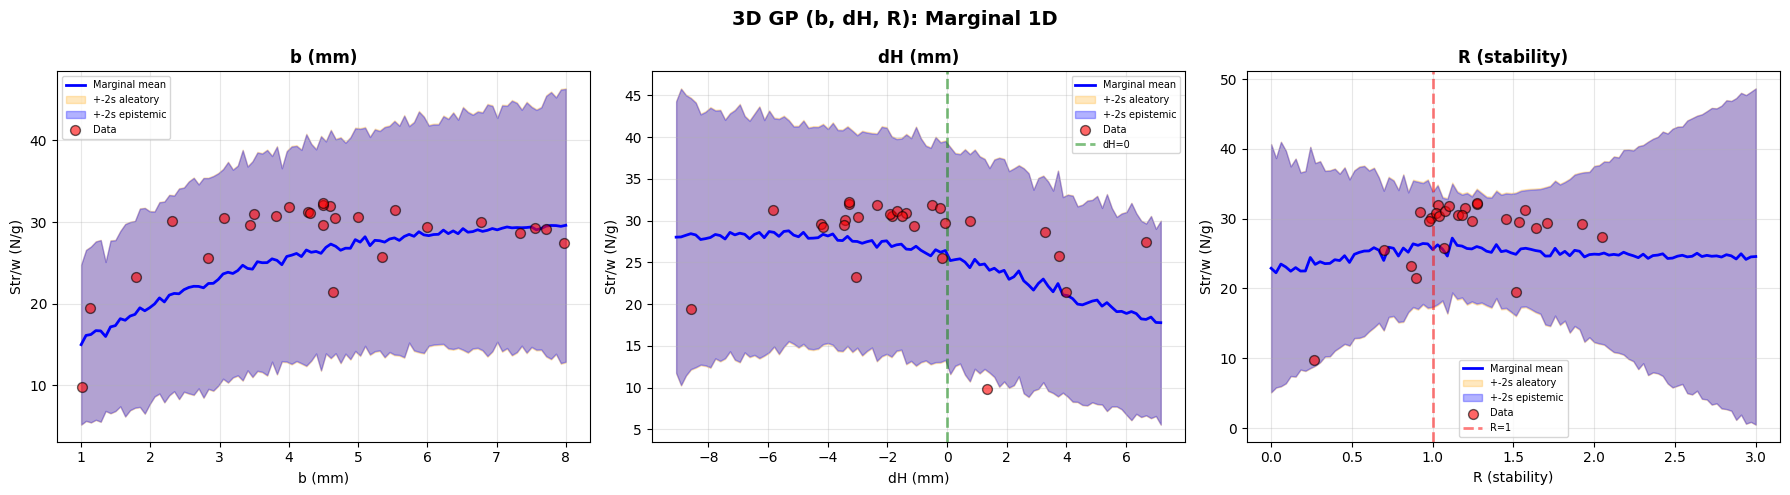

Global 1D slices (b, dH, R)...


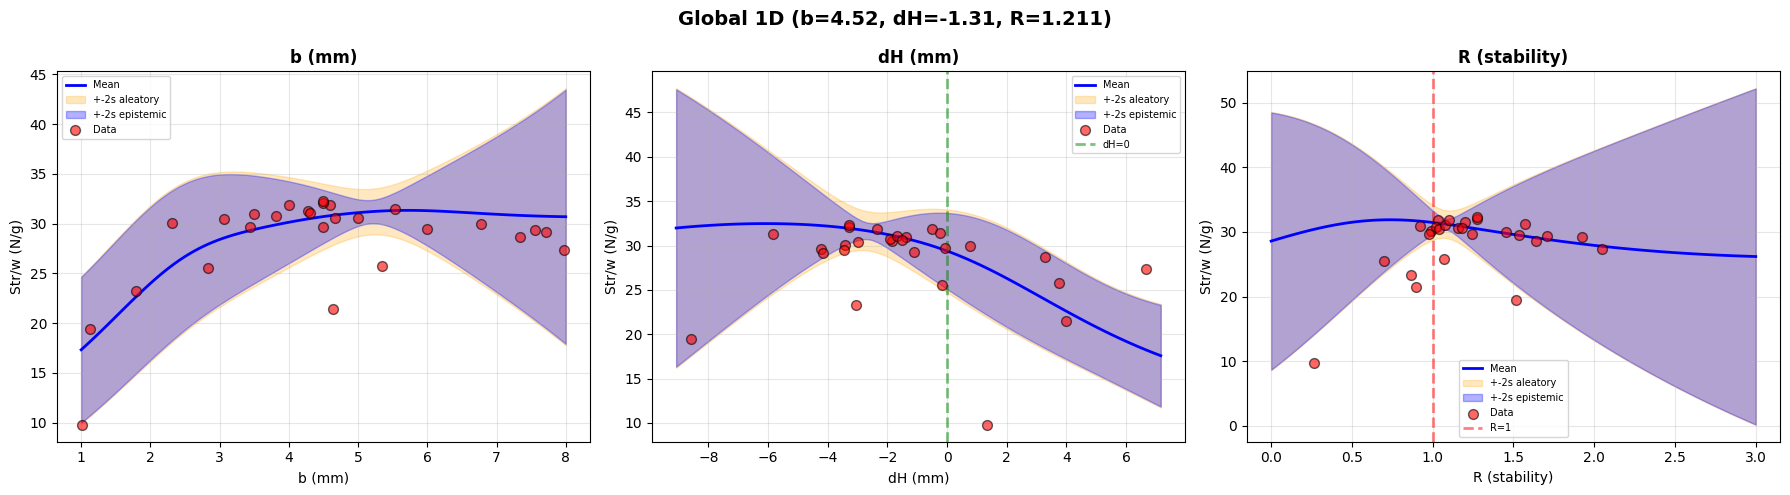

Global 2D contours (3 pairs of b, dH, R)...


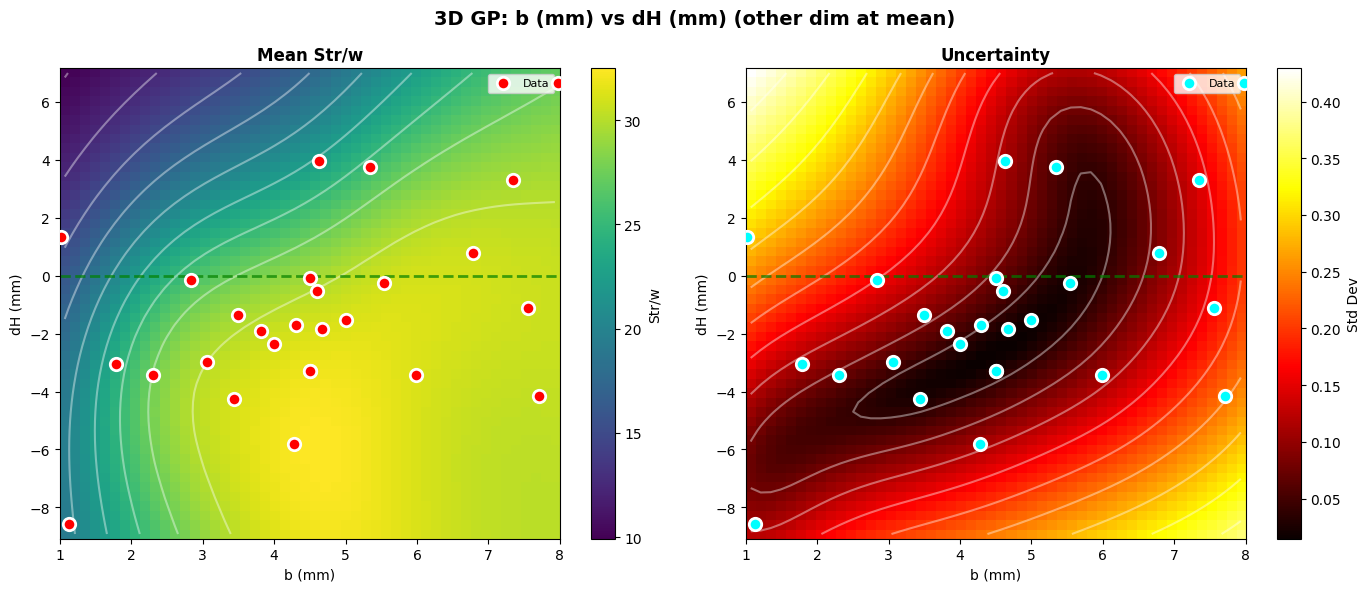

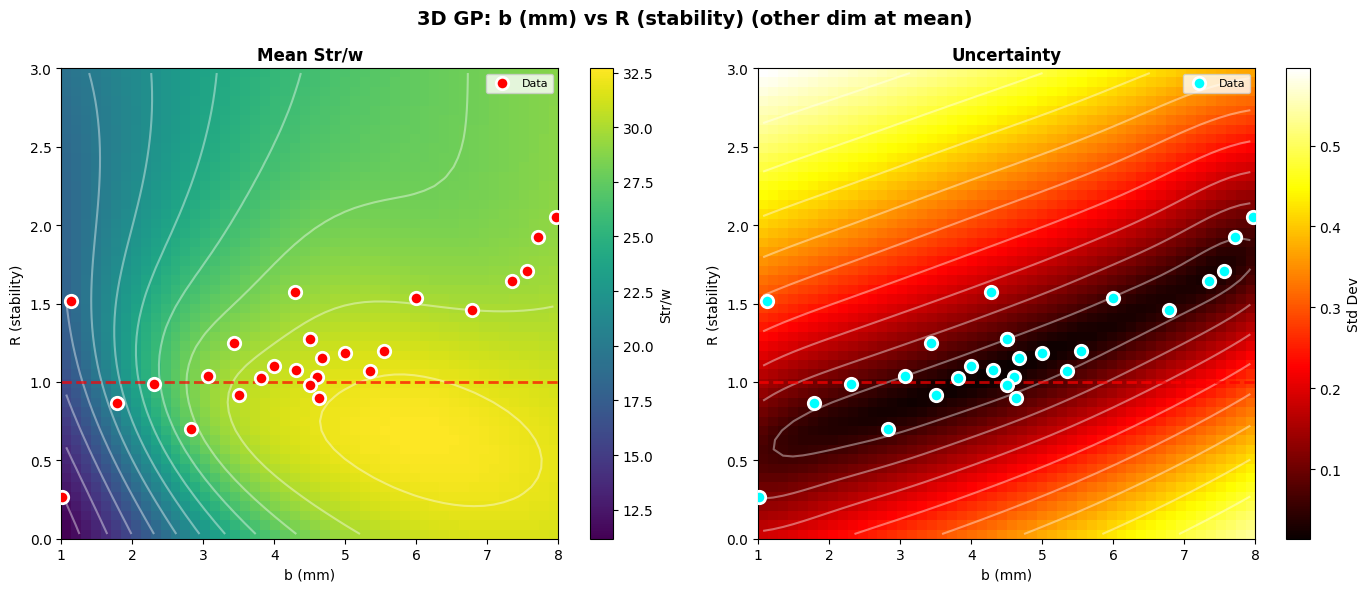

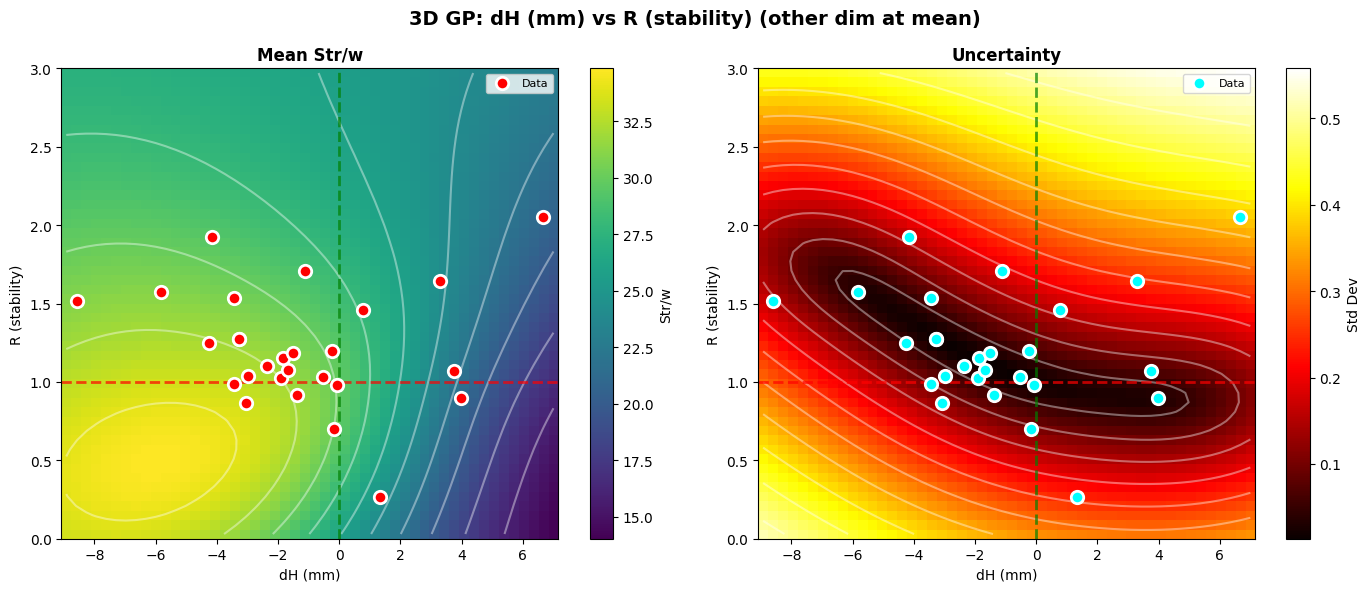

Slice 1D plots (b, dH, R)...


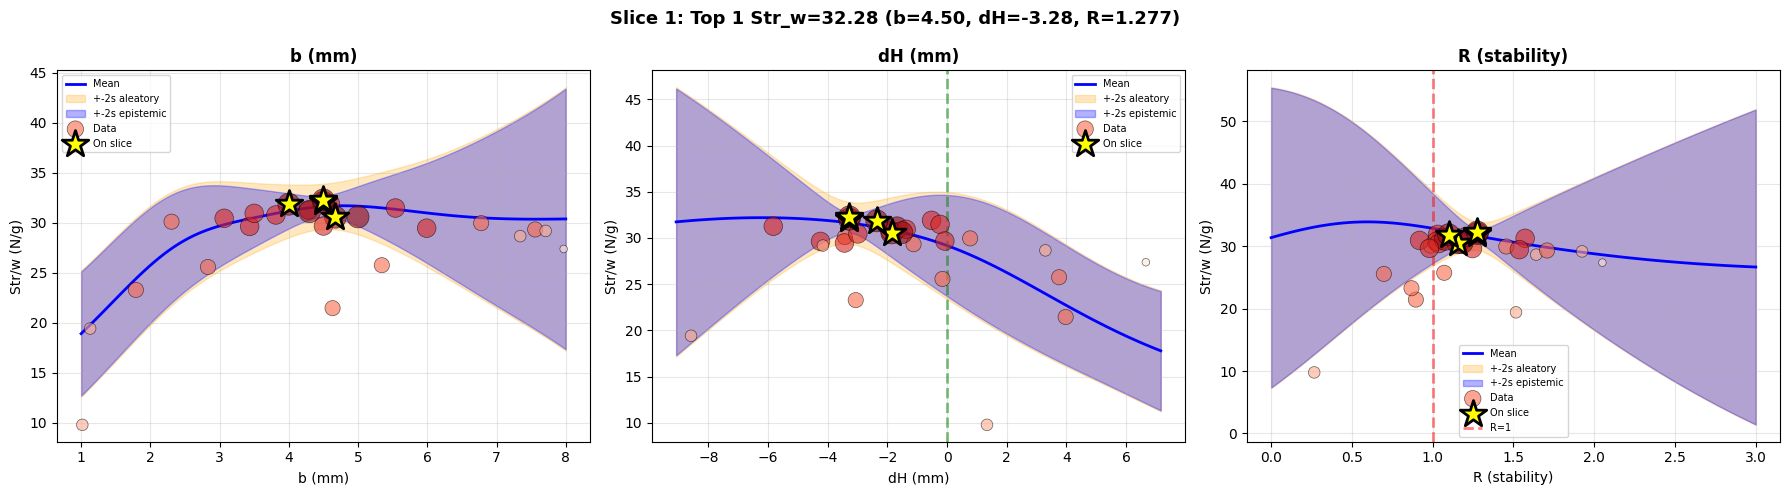

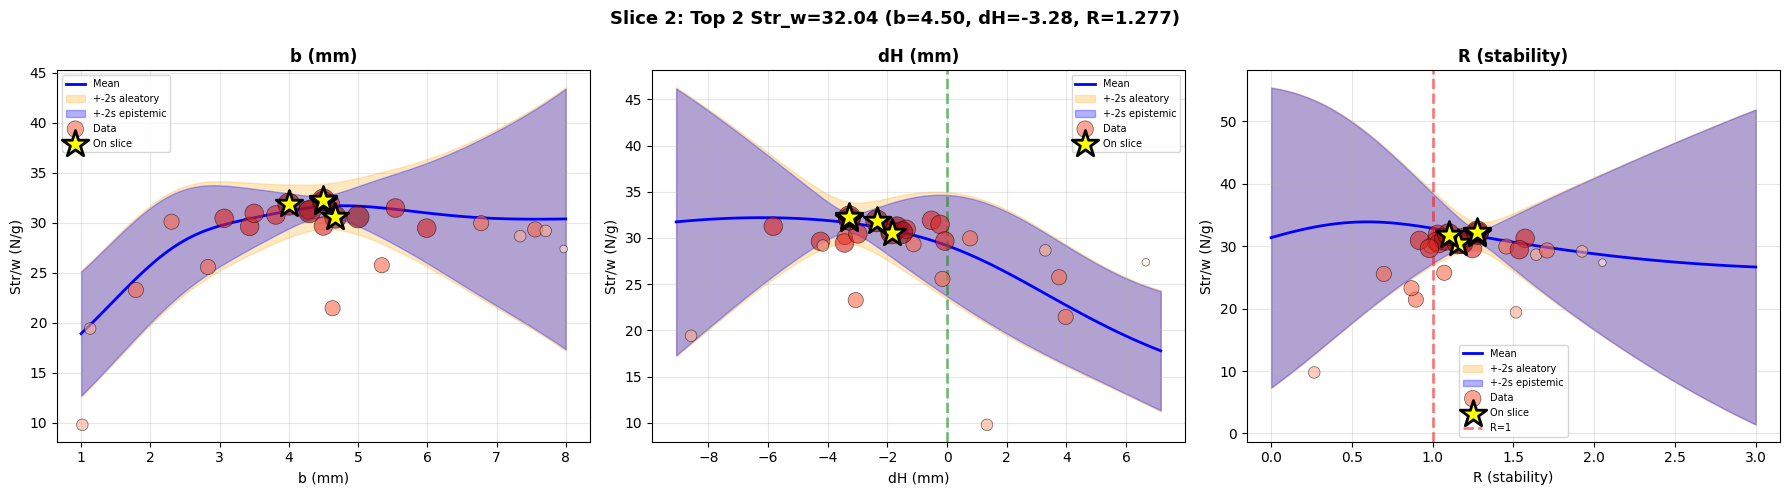

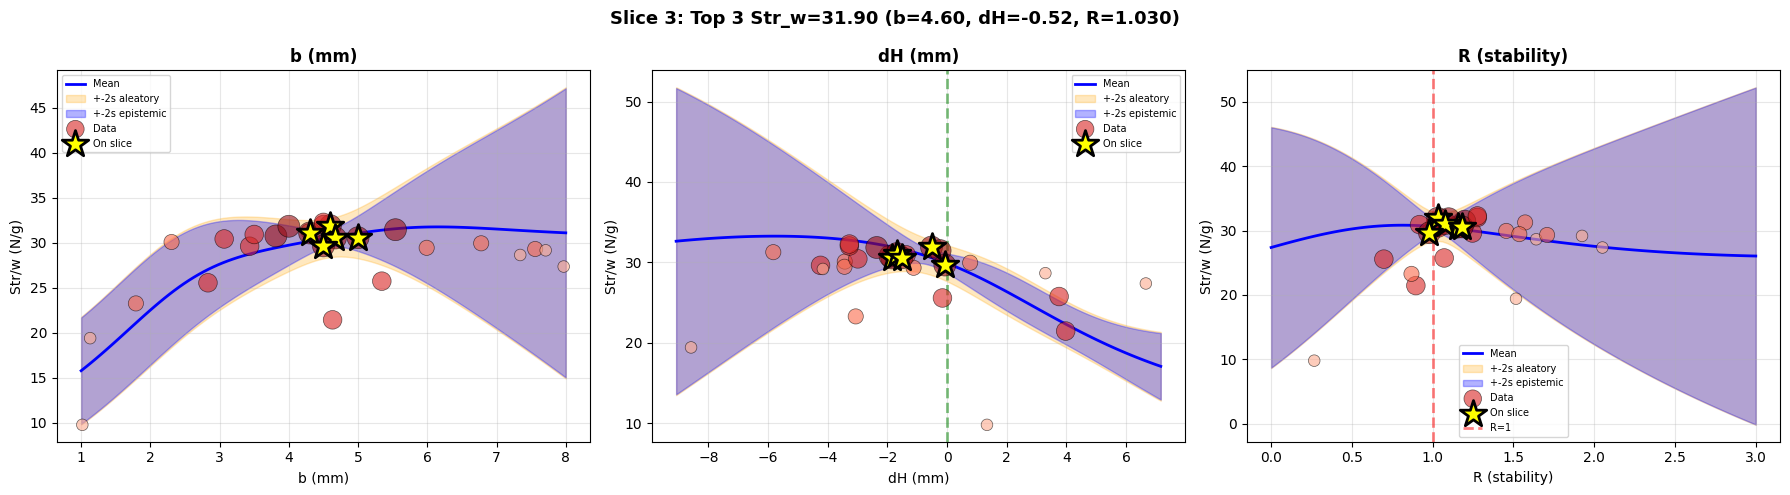

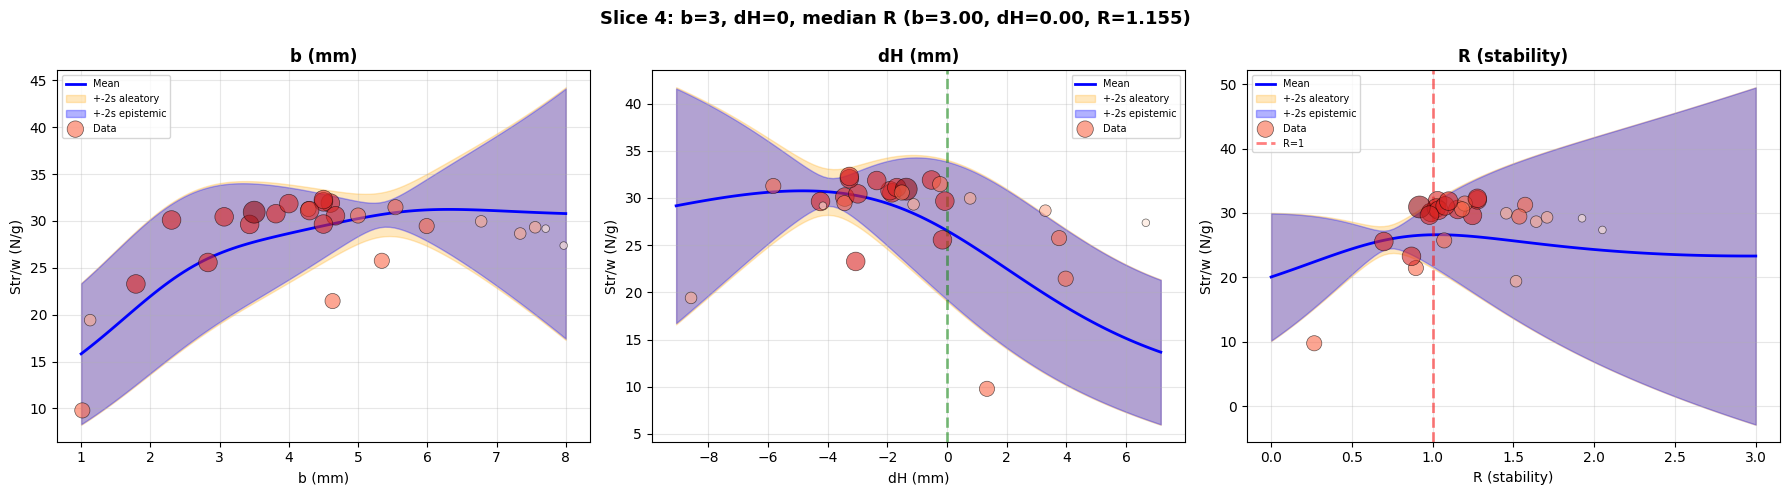

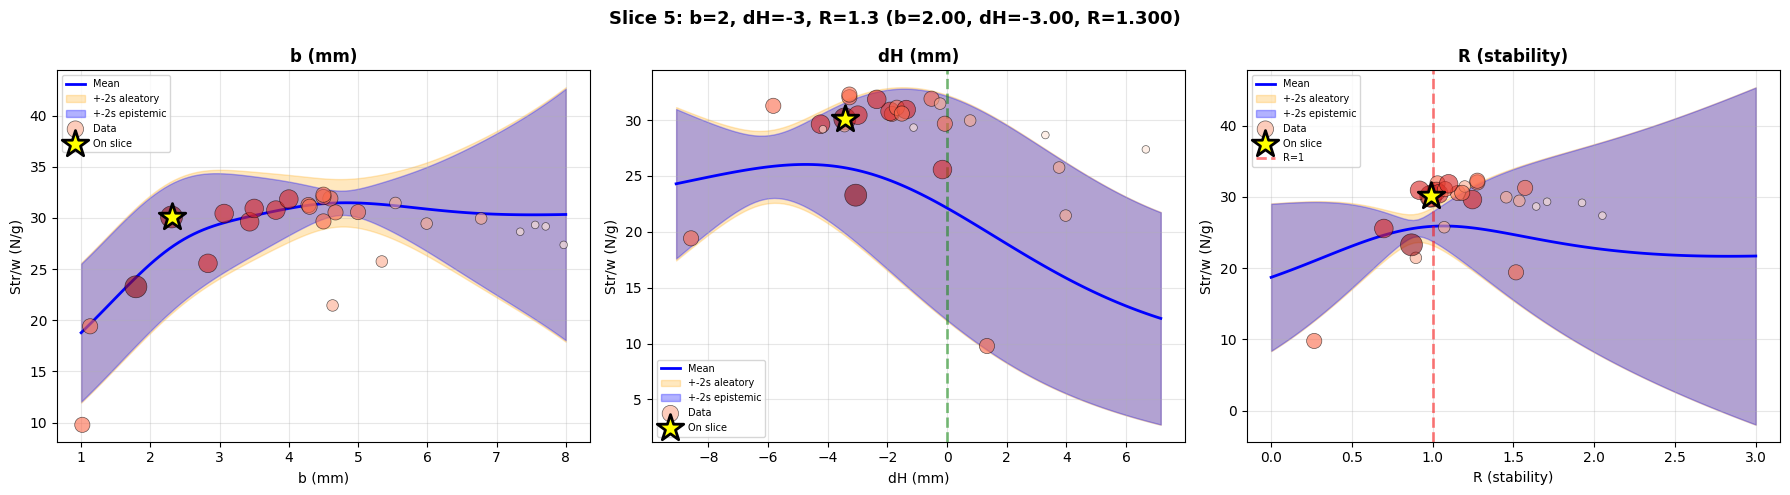


Recommendations (3D: b, dH, R)...

EI RECOMMENDATIONS (b, dH, R)

  xi=0.0001:
 Rank     b      H     dH      R  Pred  sigma
    1 4.981 12.005 -5.523 1.6238 30.78 0.0418
    2 4.998 12.061 -5.459 1.6177 30.78 0.0412
    3 4.942 12.152 -5.395 1.6016 30.85 0.0387
    4 4.980 12.204 -5.324 1.5976 30.83 0.0387
    5 4.965 12.206 -5.330 1.5962 30.85 0.0383

  xi=0.001:
 Rank     b      H     dH      R  Pred  sigma
    1 4.981 12.005 -5.523 1.6238 30.78 0.0418
    2 4.998 12.061 -5.459 1.6177 30.78 0.0412
    3 4.942 12.152 -5.395 1.6016 30.85 0.0387
    4 4.980 12.204 -5.324 1.5976 30.83 0.0387
    5 4.965 12.206 -5.330 1.5962 30.85 0.0383

  xi=0.005:
 Rank     b      H     dH      R  Pred  sigma
    1 4.981 12.005 -5.523 1.6238 30.78 0.0418
    2 4.998 12.061 -5.459 1.6177 30.78 0.0412
    3 4.942 12.152 -5.395 1.6016 30.85 0.0387
    4 4.980 12.204 -5.324 1.5976 30.83 0.0387
    5 5.058 12.211 -5.279 1.6026 30.76 0.0400

  xi=0.01:
 Rank     b      H     dH      R  Pred  sigma
    1 4.

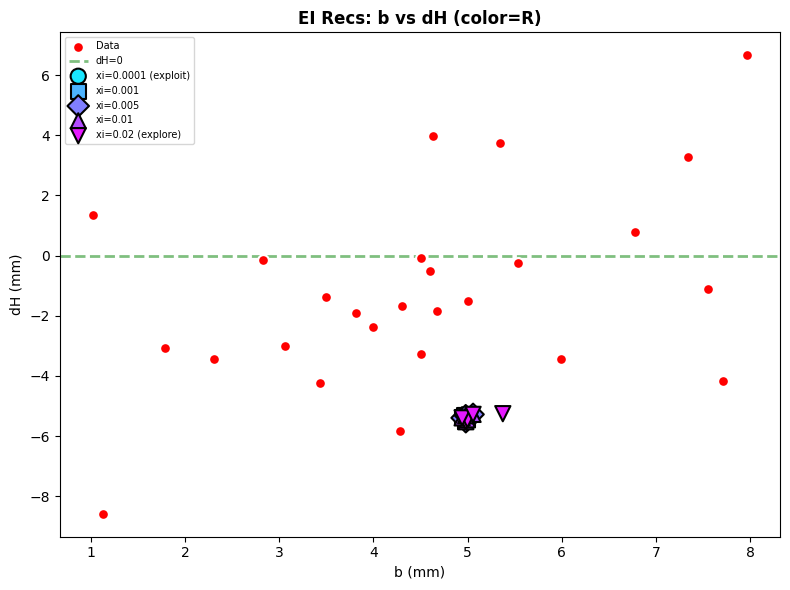

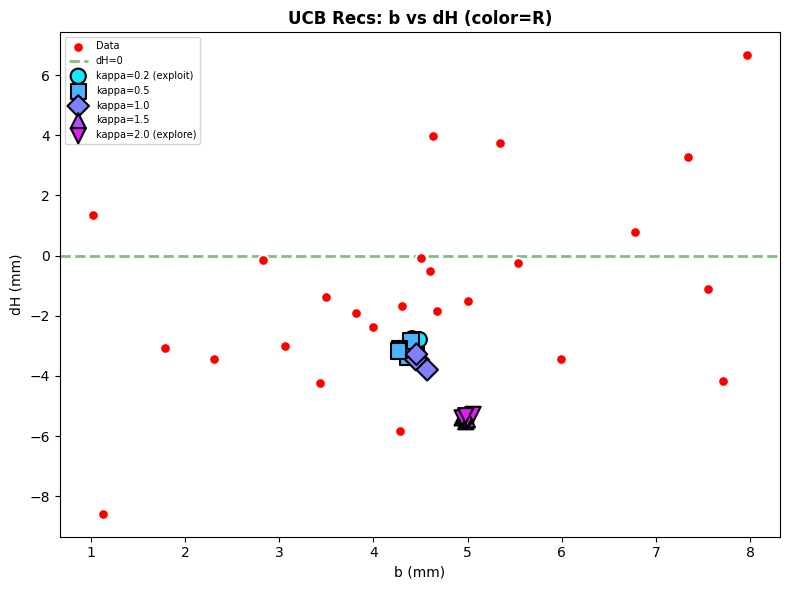


Done (3D: b, dH, R)!


In [ ]:
# ==========================================
# 3D REPARAMETERIZATION: (b, dH, R)
# ==========================================
# b is free, dH = H - H_opt(b), R = Mcr/Myield
# B=16 and r=0 fixed (2var experiment has no flangewidth or fillet variation)

from scipy.optimize import minimize_scalar
from itertools import combinations

TOTAL_HEIGHT = 25.0
B_FIXED_3 = 16.0
YIELD_STRENGTH_3 = 81.8e6     # Pa, Sunlu PLA+ 2.0
E_MODULUS_3 = 2.74e9           # Pa, Sunlu PLA+ 2.0
G_MODULUS_3 = E_MODULUS_3 / 2.6
C1_3PT_3 = 1.35
MATERIAL_DENSITY_3 = 1210     # kg/m^3
LENGTH_M_3 = 0.2023
Y_MAX_3 = TOTAL_HEIGHT / 2e3  # 0.0125 m

def _beta3(t, a):
    if a <= 0 or t <= 0: return 1.0/3.0
    r = min(t, a) / max(t, a)
    return (1.0/3.0) * (1.0 - 0.63*r + 0.052*r**5)

def _Ix(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return (b_m*H_m**3)/12 + 2*((B_m*h_m**3)/12 + B_m*h_m*((H_m+h_m)/2)**2)

def _Iy(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return (H_m*b_m**3)/12 + 2*(h_m*B_m**3)/12

def _J(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    J_web = _beta3(min(b_m, H_m), max(b_m, H_m)) * max(b_m, H_m) * min(b_m, H_m)**3
    J_fl  = _beta3(min(h_m, B_m), max(h_m, B_m)) * max(h_m, B_m) * min(h_m, B_m)**3
    return J_web + 2 * J_fl

def _mass(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return MATERIAL_DENSITY_3 * LENGTH_M_3 * (H_m*b_m + 2*h_m*B_m) * 1000

def _str_w(H, B, b):
    h = (TOTAL_HEIGHT - H) / 2.0
    s = (4 * YIELD_STRENGTH_3 * _Ix(H, h, B, b)) / (Y_MAX_3 * LENGTH_M_3)
    m = _mass(H, h, B, b)
    return s / m if m > 0 else 0.0

def _H_opt(b, B=B_FIXED_3):
    def obj(H):
        if H < 12.0 or H > 23.4: return 1e10
        h = (TOTAL_HEIGHT - H) / 2.0
        if h < 0 or h > 6.5: return 1e10
        return -_str_w(H, B, b)
    return minimize_scalar(obj, bounds=(12.0, 23.4), method='bounded').x

def _R(H, h, B, b):
    Iy = _Iy(H, h, B, b); J = _J(H, h, B, b)
    if Iy <= 0 or J <= 0: return 0.0
    Mcr = (C1_3PT_3 * np.pi / LENGTH_M_3) * np.sqrt(E_MODULUS_3 * Iy * G_MODULUS_3 * J)
    Ix = _Ix(H, h, B, b)
    My = YIELD_STRENGTH_3 * Ix / Y_MAX_3 if Y_MAX_3 > 0 else 0.0
    return Mcr / My if My > 0 else 0.0

def bH_to_3d(b_arr, H_arr):
    n = len(b_arr)
    out = np.zeros((n, 3))
    for i in range(n):
        Hopt = _H_opt(b_arr[i])
        out[i, 0] = b_arr[i]
        out[i, 1] = H_arr[i] - Hopt
        h = (TOTAL_HEIGHT - H_arr[i]) / 2.0
        out[i, 2] = _R(H_arr[i], h, B_FIXED_3, b_arr[i]) if h > 0 else 0.0
    return out

# Transform original data
X_3 = bH_to_3d(X_2d[:, 0], X_2d[:, 1])

print("3D data (b, dH, R):")
print(f"{'#':>3} {'b':>6} {'H':>6} {'dH':>7} {'R':>7} {'Str/w':>7}")
for i in range(len(y)):
    print(f"{i+1:3d} {X_2d[i,0]:6.2f} {X_2d[i,1]:6.2f} {X_3[i,1]:7.2f} {X_3[i,2]:7.3f} {y[i]:7.2f}")

# Bounds from data + margin
BOUNDS_3 = {
    'b':  (1.0, 8.0),
    'dH': (X_3[:,1].min() - 0.5, X_3[:,1].max() + 0.5),
    'R':  (0.0, max(X_3[:,2].max() * 1.1, 3.0)),
}
PK3 = list(BOUNDS_3.keys())
PN3 = ['b (mm)', 'dH (mm)', 'R (stability)']
PLOT_DIMS_3 = [0, 1, 2]

def norm3(X):
    X_n = np.copy(X).astype(float)
    for i, k in enumerate(PK3):
        lo, hi = BOUNDS_3[k]
        X_n[:, i] = (X[:, i] - lo) / (hi - lo)
    return X_n

def denorm3(X_n):
    X = np.copy(X_n)
    for i, k in enumerate(PK3):
        lo, hi = BOUNDS_3[k]
        X[:, i] = X_n[:, i] * (hi - lo) + lo
    return X

# Train 3D GP
print(f"\nTraining 3D GP (b, dH, R), alpha={NOISE_LEVEL}...")
X_n3 = norm3(X_3)
y_log3 = np.log(y); ym3 = np.mean(y_log3); yc3 = y_log3 - ym3
kern3 = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
    length_scale=[0.5]*3, length_scale_bounds=(0.1, 3.0), nu=2.5)
gp3 = GaussianProcessRegressor(kernel=kern3, n_restarts_optimizer=25,
                                 alpha=NOISE_LEVEL, normalize_y=False)
gp3.fit(X_n3, yc3)
ls3 = gp3.kernel_.k2.length_scale
print(f"ARD length scales: b={ls3[0]:.3f}, dH={ls3[1]:.3f}, R={ls3[2]:.3f}")

# ---- helpers ----
def _bands3(ax, x, mu_r):
    ep = mu_r * 0  # will be set by caller
    return  # placeholder, handled inline

def _get_sizes3(X_n, pt):
    d = np.linalg.norm(X_n - pt, axis=1)
    sizes = np.where(d<0.15, 250, np.where(d<0.30, 180, np.where(d<0.50, 120, np.where(d<0.75, 70, 30))))
    colors = np.where(d<0.15, 0.9, np.where(d<0.30, 0.7, np.where(d<0.50, 0.5, np.where(d<0.75, 0.3, 0.1))))
    return sizes, d, colors

# ---- MARGINAL 1D ----
print("\nMarginal 1D (b, dH, R)...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3D GP (b, dH, R): Marginal 1D', fontsize=14, weight='bold')
for dim in range(3):
    ax = axes[dim]
    x_norm = np.linspace(0, 1, 100)
    mu_all, sig_all = [], []
    for xv in x_norm:
        samp = np.random.rand(200, 3); samp[:, dim] = xv
        mu, sig = gp3.predict(samp, return_std=True)
        mu_all.append(np.mean(mu)); sig_all.append(np.mean(sig))
    mu_avg, sig_avg = np.array(mu_all), np.array(sig_all)
    mu_r = np.exp(mu_avg + ym3); ep = mu_r * sig_avg
    al = mu_r * np.sqrt(NOISE_LEVEL); tot = np.sqrt(ep**2 + al**2)
    lo, hi = BOUNDS_3[PK3[dim]]; xv = x_norm*(hi-lo)+lo
    ax.plot(xv, mu_r, 'b-', lw=2, label='Marginal mean')
    ax.fill_between(xv, mu_r-2*tot, mu_r+2*tot, alpha=0.25, color='orange', label='+-2s aleatory')
    ax.fill_between(xv, mu_r-2*ep, mu_r+2*ep, alpha=0.3, color='blue', label='+-2s epistemic')
    Xd = denorm3(X_n3)
    ax.scatter(Xd[:, dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
    if dim == 1: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2, label='dH=0')
    if dim == 2: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1')
    ax.set_xlabel(PN3[dim]); ax.set_ylabel('Str/w (N/g)')
    ax.set_title(PN3[dim], weight='bold'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- GLOBAL 1D ----
print("Global 1D slices (b, dH, R)...")
sp3 = np.mean(X_n3, axis=0)
sr3 = denorm3(sp3.reshape(1,-1))[0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Global 1D (b={sr3[0]:.2f}, dH={sr3[1]:.2f}, R={sr3[2]:.3f})', fontsize=14, weight='bold')
for dim in range(3):
    ax = axes[dim]
    Xt = np.tile(sp3, (100,1)); Xt[:,dim] = np.linspace(0,1,100)
    mu, sig = gp3.predict(Xt, return_std=True)
    mu_r = np.exp(mu+ym3); ep = mu_r*sig
    al = mu_r*np.sqrt(NOISE_LEVEL); tot = np.sqrt(ep**2+al**2)
    xv = denorm3(Xt)[:,dim]
    ax.plot(xv, mu_r, 'b-', lw=2, label='Mean')
    ax.fill_between(xv, mu_r-2*tot, mu_r+2*tot, alpha=0.25, color='orange', label='+-2s aleatory')
    ax.fill_between(xv, mu_r-2*ep, mu_r+2*ep, alpha=0.3, color='blue', label='+-2s epistemic')
    Xd = denorm3(X_n3)
    ax.scatter(Xd[:,dim], y, c='red', s=50, alpha=0.6, ec='black', lw=1, zorder=5, label='Data')
    if dim==1: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2, label='dH=0')
    if dim==2: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1')
    ax.set_xlabel(PN3[dim]); ax.set_ylabel('Str/w (N/g)')
    ax.set_title(PN3[dim], weight='bold'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- GLOBAL 2D (3 pairs) ----
print("Global 2D contours (3 pairs of b, dH, R)...")
combos = list(combinations(range(3), 2))
for d1, d2 in combos:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'3D GP: {PN3[d1]} vs {PN3[d2]} (other dim at mean)', fontsize=14, weight='bold')
    res = 50
    gx, gy = np.meshgrid(np.linspace(0,1,res), np.linspace(0,1,res))
    Xt = np.tile(sp3, (res*res,1)); Xt[:,d1]=gx.ravel(); Xt[:,d2]=gy.ravel()
    mu, sig = gp3.predict(Xt, return_std=True)
    mu_r = np.exp(mu+ym3).reshape(res,res); sig_r = sig.reshape(res,res)
    xv = np.linspace(*BOUNDS_3[PK3[d1]], res); yv = np.linspace(*BOUNDS_3[PK3[d2]], res)
    ext = [xv[0], xv[-1], yv[0], yv[-1]]
    Xd = denorm3(X_n3)

    im1 = axes[0].imshow(mu_r, origin='lower', extent=ext, aspect='auto', cmap='viridis')
    axes[0].contour(mu_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[0].scatter(Xd[:,d1], Xd[:,d2], c='red', s=80, ec='white', lw=2, zorder=10, label='Data')
    if d1==1 or d2==1:
        (axes[0].axhline if d2==1 else axes[0].axvline)(0, color='green', ls='--', lw=2, alpha=0.7)
    if d1==2 or d2==2:
        (axes[0].axhline if d2==2 else axes[0].axvline)(1.0, color='red', ls='--', lw=2, alpha=0.7)
    axes[0].set_xlabel(PN3[d1]); axes[0].set_ylabel(PN3[d2])
    axes[0].set_title('Mean Str/w', weight='bold'); axes[0].legend(fontsize=8)
    plt.colorbar(im1, ax=axes[0], label='Str/w')

    im2 = axes[1].imshow(sig_r, origin='lower', extent=ext, aspect='auto', cmap='hot')
    axes[1].contour(sig_r, origin='lower', extent=ext, colors='white', alpha=0.4, levels=10)
    axes[1].scatter(Xd[:,d1], Xd[:,d2], c='cyan', s=80, ec='white', lw=2, zorder=10, label='Data')
    if d1==1 or d2==1:
        (axes[1].axhline if d2==1 else axes[1].axvline)(0, color='green', ls='--', lw=2, alpha=0.7)
    if d1==2 or d2==2:
        (axes[1].axhline if d2==2 else axes[1].axvline)(1.0, color='red', ls='--', lw=2, alpha=0.7)
    axes[1].set_xlabel(PN3[d1]); axes[1].set_ylabel(PN3[d2])
    axes[1].set_title('Uncertainty', weight='bold'); axes[1].legend(fontsize=8)
    plt.colorbar(im2, ax=axes[1], label='Std Dev')
    plt.tight_layout(); plt.show()

# ---- SLICE 1D ----
print("Slice 1D plots (b, dH, R)...")
slices3 = []
top3_idx = np.argsort(y)[-3:][::-1]
for i, idx in enumerate(top3_idx):
    slices3.append((X_3[idx], f"Top {i+1} Str_w={y[idx]:.2f}"))
slices3.append((np.array([3.0, 0.0, np.median(X_3[:,2])]), "b=3, dH=0, median R"))
slices3.append((np.array([2.0, -3.0, 1.3]), "b=2, dH=-3, R=1.3"))

for si, (pt, name) in enumerate(slices3):
    pt_n = norm3(pt.reshape(1,-1))[0]
    pt_r = denorm3(pt_n.reshape(1,-1))[0]
    sizes, dists, colors = _get_sizes3(X_n3, pt_n)
    on_slice = dists < 0.12
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Slice {si+1}: {name} (b={pt_r[0]:.2f}, dH={pt_r[1]:.2f}, R={pt_r[2]:.3f})',
                 fontsize=13, weight='bold')
    for dim in range(3):
        ax = axes[dim]
        Xt = np.tile(pt_n, (100,1)); Xt[:,dim] = np.linspace(0,1,100)
        mu, sig = gp3.predict(Xt, return_std=True)
        mu_r = np.exp(mu+ym3); ep = mu_r*sig
        al = mu_r*np.sqrt(NOISE_LEVEL); tot = np.sqrt(ep**2+al**2)
        xv = denorm3(Xt)[:,dim]
        ax.plot(xv, mu_r, 'b-', lw=2, label='Mean')
        ax.fill_between(xv, mu_r-2*tot, mu_r+2*tot, alpha=0.25, color='orange', label='+-2s aleatory')
        ax.fill_between(xv, mu_r-2*ep, mu_r+2*ep, alpha=0.3, color='blue', label='+-2s epistemic')
        Xd = denorm3(X_n3)
        ax.scatter(Xd[:,dim], y, s=sizes, c=colors, cmap='Reds', vmin=0, vmax=1,
                  alpha=0.6, ec='black', lw=0.5, zorder=5, label='Data')
        if np.any(on_slice):
            ax.scatter(Xd[on_slice,dim], y[on_slice], s=400, marker='*',
                      c='yellow', ec='black', lw=2, zorder=10, label='On slice')
        if dim==1: ax.axvline(0, color='green', ls='--', alpha=0.5, lw=2)
        if dim==2: ax.axvline(1.0, color='red', ls='--', alpha=0.5, lw=2, label='R=1')
        ax.set_xlabel(PN3[dim]); ax.set_ylabel('Str/w (N/g)')
        ax.set_title(PN3[dim], weight='bold'); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

# ---- EI / UCB RECOMMENDATIONS ----
print("\nRecommendations (3D: b, dH, R)...")
# Generate candidates in physical (b, H) then map to 3D
cand_b3 = np.random.uniform(*BOUNDS['b'], size=5000)
cand_H3 = np.random.uniform(*BOUNDS['H'], size=5000)
cand_3 = bH_to_3d(cand_b3, cand_H3)
cand_n3 = norm3(cand_3)

xi_vals = [0.0001, 0.001, 0.005, 0.01, 0.02]
kappa_vals = [0.2, 0.5, 1.0, 1.5, 2.0]
yb3 = yc3.max()
rows3 = []

for xi in xi_vals:
    acq, mu, sig = ei_acq(gp3, cand_n3, yb3, xi)
    top = np.argsort(acq)[-5:][::-1]
    for rank, idx in enumerate(top, 1):
        rows3.append({'Method':'EI', 'Setting':f'xi={xi}', 'Rank':rank,
            'b':round(cand_b3[idx],3), 'H':round(cand_H3[idx],3),
            'dH':round(cand_3[idx,1],3), 'R':round(cand_3[idx,2],4),
            'Pred':round(np.exp(mu[idx]+ym3),2), 'sigma':round(sig[idx],4)})
for kappa in kappa_vals:
    acq, mu, sig = ucb_acq(gp3, cand_n3, kappa)
    top = np.argsort(acq)[-5:][::-1]
    for rank, idx in enumerate(top, 1):
        rows3.append({'Method':'UCB', 'Setting':f'kappa={kappa}', 'Rank':rank,
            'b':round(cand_b3[idx],3), 'H':round(cand_H3[idx],3),
            'dH':round(cand_3[idx,1],3), 'R':round(cand_3[idx,2],4),
            'Pred':round(np.exp(mu[idx]+ym3),2), 'sigma':round(sig[idx],4)})

rec3 = pd.DataFrame(rows3)
for method in ['EI', 'UCB']:
    print(f"\n{'='*70}\n{method} RECOMMENDATIONS (b, dH, R)\n{'='*70}")
    sub = rec3[rec3['Method']==method]
    for setting in sub['Setting'].unique():
        ss = sub[sub['Setting']==setting]
        print(f"\n  {setting}:")
        print(ss[['Rank','b','H','dH','R','Pred','sigma']].to_string(index=False))

# Recommendation scatter on b vs dH
for method in ['EI', 'UCB']:
    sub = rec3[rec3['Method']==method]; settings = sub['Setting'].unique()
    fig, ax = plt.subplots(figsize=(8,6))
    Xd = denorm3(X_n3)
    ax.scatter(Xd[:,0], Xd[:,1], c='red', s=60, ec='white', lw=1.5, zorder=10, label='Data')
    ax.axhline(0, color='green', ls='--', lw=2, alpha=0.5, label='dH=0')
    markers = ['o','s','D','^','v']
    cm = plt.cm.cool(np.linspace(0.1, 0.9, len(settings)))
    for i, (s, c) in enumerate(zip(settings, cm)):
        ss = sub[sub['Setting']==s]
        tag = 'exploit' if i==0 else ('explore' if i==len(settings)-1 else '')
        lab = f"{s}" + (f" ({tag})" if tag else "")
        ax.scatter(ss['b'], ss['dH'], c=[c]*len(ss), s=120, marker=markers[i%5],
                  ec='black', lw=1.5, zorder=11, label=lab)
    ax.set_xlabel('b (mm)'); ax.set_ylabel('dH (mm)')
    ax.set_title(f'{method} Recs: b vs dH (color=R)', fontsize=12, weight='bold')
    ax.legend(fontsize=7); plt.tight_layout(); plt.show()

print("\nDone (3D: b, dH, R)!")